# Kaggriculture: Precomputed Schedule Policy

Terminal bank decides the game, and both seats bank through one market:
every unit bought or sold moves a shared public inventory, and every
quote is a fixed function of that inventory. A strategy here is
therefore judged on the joint path it produces with its counterpart,
not on its rules in isolation. A complete strong episode is an observed
equilibrium path of exactly this coupled system - a joint action
sequence in which two full-strength plans were executed against each
other, with every price along the way set by their combined flow.

This notebook commits to such a path. The policy below is a complete
720-turn action program $\sigma$, fixed before the first observation
arrives. Replaying an equilibrium path commits to a strategy that was
*measured* at equilibrium rather than reasoned to from modelling
assumptions. The sections derive the coupling that makes the commitment
coherent, state precisely what it buys and what it costs, and verify
the program end to end.


In [1]:
import subprocess
import sys

# The engine below must be the build the schedule is specified against:
# under any other build the same action stream clears at different
# prices, and the changed cash changes which money-gated orders land.
# The preinstalled image lags, so the pin is installed and asserted.
ENGINE = "1.32.7"
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     f"kaggle-environments=={ENGINE}"],
    check=True,
)
import kaggle_environments
assert kaggle_environments.__version__ == ENGINE, kaggle_environments.__version__


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 57.7 MB/s eta 0:00:00


In [2]:
from pathlib import Path
from IPython.core.magic import register_cell_magic

WORK_DIR = (
    Path("/kaggle/working")
    if Path("/kaggle/working").is_dir()
    else Path.cwd() / "policy_bundle_output"
)
WORK_DIR.mkdir(parents=True, exist_ok=True)
MAIN_PATH = WORK_DIR / "main.py"

@register_cell_magic
def agentfile(line, cell):
    mode = "a" if line.strip() == "append" else "w"
    with MAIN_PATH.open(mode, encoding="utf-8") as handle:
        handle.write(cell)


## 1. One market, two seats

Let $I_{r,t}$ be the public inventory of product $r$ after turn $t$.
Both seats trade against the same $I_{r,t}$: a sale adds to it, a
purchase draws it down, and the town's consumption walks it lower on a
fixed clock. The quote is a deterministic map of this shared state,

$$
p_r(I)=
\max\!\Big(1,\ \big[\,b_r + a_r^{-}\,f_r^{-}(I_0-I)\,\big]\Big)
\ \ (I<I_0),
\qquad
p_r(I)=
\max\!\Big(1,\ \big[\,b_r - a_r^{+}\,f_r^{+}(I-I_0)\,\big]\Big)
\ \ (I\ge I_0),
$$

with $I_0=10{,}000$, $[\cdot]$ rounding to the nearest integer, and a
shape chosen per product and per side from the family

$$
f\in\Big\{x,\ x^{2},\ \sqrt{x},\ \log(1+x),\ \mathrm{hinge}\Big\},
\qquad
\mathrm{hinge}:\ f(x)=u+8\max(0,\,u-1)^{2},\ \ u=\tfrac{x}{T_r}.
$$

Each amplitude $a_r^{\pm}$ is normalised so the curve reaches its
target multiple of the base price $b_r$ exactly at depth $T_r$. Three
products - carrot, tomato, egg - carry the hinge on their scarcity
side: linear in the deficit up to the knee at $I_0-T_r$, quadratic
growth past it. The same product is calm at moderate scarcity and
violently elastic once the deficit crosses the knee, and both regimes
live on the *same* side of $I_0$.

The market clears unit by unit, so a block of $x$ units sold from
inventory $I$ realises

$$
R(x\mid I)=\sum_{i=0}^{x-1}p_r(I+i),
$$

and every unit the counterpart moves relocates the start of that sum.
A policy's payoff is therefore not a function of its own action stream;
it is a functional of the joint path $\{(a_t^{(0)},a_t^{(1)})\}_t$
through the shared state. A best response in such a game answers a
whole trajectory, not a rule - it is path-dependent. A time-indexed
schedule is the object that encodes a path: a strategy stated in
exactly the coordinates in which the game is scored.


## 2. The schedule as a policy

The policy below is a map

$$
\sigma:\{0,\dots,719\}\to\mathcal A,
\qquad
\sigma(t)=
\big(a_t^{\mathrm{farmer}},\,a_t^{\mathrm{hands}},\,a_t^{\mathrm{market}}\big),
$$

from the turn index alone to a complete action tuple - one farmer
command, one command per hand, an ordered market list. It is
observation-independent by construction: $\sigma$ reads the clock and
nothing else.

**What the commitment buys.** A reactive policy acts through a model of
what it observes: yield forecasts, price forecasts, a value for labor.
Each estimate carries error, and re-planning against one's own past
actions can oscillate - plan $k+1$ optimises against a state plan $k$
created, and partially undoes it. $\sigma$ carries neither failure
mode. The action at turn $t$ was determined jointly with the actions of
every other turn, so the internal consistency of the program -
planting, watering, feeding, harvest, transport, and sale each in time
for the next - is exact rather than estimated, and nothing is
re-derived mid-season, so there is nothing to oscillate.

**What the commitment costs.** The season's demand is a random
variable, and $\sigma$ cannot see the draw. Every third day the town
draws one shop uniformly, with replacement, from eight types, up to
eight instances; each instance consumes its fixed product basket on a
fixed clock for the rest of the season, and the town centre adds one
unit of demand per day for every product except fertilizer. A product
carried by exactly one shop type is therefore absent from the drawn
demand with probability $(7/8)^{8}\approx 0.34$: in one season in
three, its demand is the town centre's thirty units, however much is
grown. A schedule sized against one realised draw will generally meet
another - sometimes richer, sometimes thinner, than the demand it was
measured on. The counterpart is the same kind of variance: at the
committed path's own equilibrium the prices are exactly those the
program realised, while against a different counterpart the same
actions clear at different prices. The commitment accepts both
variances in exchange for exactness everywhere else. What survives
every draw is the production side: maturities, service windows, and
terminal feasibility are properties of the farm alone, and the program
keeps them by construction.


## 3. Execution invariants

Along its measured path the program's output satisfies the engine's
per-turn action bounds - one farmer command, one command per hired
hand, and an ordered market list of at most ten orders,

$$
|a_t^{\mathrm{hands}}| = H_t,
\qquad
|a_t^{\mathrm{market}}|\le 10 .
$$

Off the measured path the engine degrades gracefully rather than
faulting: an order the state cannot support - a purchase the bank
cannot cover, a harvest with nothing mature - resolves to a no-op, and
a command addressed to a unit that does not exist is discarded. A
committed program therefore remains legal on every path, not only the
one it was measured on.

The runtime binds the **last callable** defined in the submitted file
as the acting agent, so the file below ends with its `agent` function.
That function is total: the turn index is read defensively (a malformed
observation cannot raise), a turn inside the program returns a deep
copy of the scheduled tuple - a copy, so no caller can mutate the
program - and any turn beyond the program returns the safe action:
farmer `PASS`, one `PASS` per visible hand, an empty market list.


In [3]:
%%agentfile
"""Exact public replay tape: episode 93311715, seat 0."""
import copy

EPISODE_ID = 93311715
SOURCE_SEAT = 0
ALIGNED_ACTION_COUNT = 719
TRACE_ACTIONS = [{'farmer': ['BUILD_PASTURE'],
  'hands': [],
  'market': [['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['BUY_ANIMAL', 'COW', 2],
             ['BUY_ANIMAL', 'SHEEP', 2],
             ['BUY_SEED', 'WHEAT', 7],
             ['BUY_SEED', 'MELON', 12],
             ['BUY_PRODUCT', 'WHEAT', 6]]},
 {'farmer': ['PICKUP', 'SHEEP', 1],
  'hands': [['WEST'], ['NORTH'], ['WEST'], ['WEST'], ['WEST']],
  'market': [['SELL', 'WHEAT', 2]]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'SHEEP', 1], ['NORTH'], ['NORTH'], ['BUILD_PASTURE'], ['WEST']],
  'market': []},
 {'farmer': ['BUILD_PASTURE'],
  'hands': [['WEST'], ['NORTH'], ['PICKUP', 'COW', 1], ['WEST'], ['NORTH']],
  'market': []},
 {'farmer': ['PLACE', 'SHEEP', 1],
  'hands': [['NORTH'], ['NORTH'], ['PLACE', 'COW', 1], ['WEST'], ['BUILD_PASTURE']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['PLACE', 'SHEEP', 1],
            ['PLANT', 'WHEAT'],
            ['PICKUP', 'WHEAT', 1],
            ['PLANT', 'WHEAT'],
            ['WEST']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['WEST'], ['WATER'], ['NORTH'], ['WATER'], ['NORTH']],
  'market': [['BUY_PRODUCT', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['WEST'], ['WEST'], ['FEED'], ['WEST'], ['PLANT', 'WHEAT']],
  'market': []},
 {'farmer': ['PICKUP', 'WHEAT', 1],
  'hands': [['PLANT', 'WHEAT'], ['NORTH'], ['CARE'], ['PLANT', 'MELON'], ['WATER']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['WATER'], ['PLANT', 'WHEAT'], ['SOUTH'], ['WATER'], ['WEST']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['NORTH'], ['WATER'], ['PICKUP', 'COW', 1], ['NORTH'], ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['PLANT', 'MELON'], ['WEST'], ['WEST'], ['PLANT', 'MELON'], ['PLANT', 'WHEAT']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['WATER'], ['PLANT', 'MELON'], ['PLACE', 'COW', 1], ['WATER'], ['WATER']],
  'market': [['BUY_PRODUCT', 'WHEAT', 1]]},
 {'farmer': ['NORTH'], 'hands': [['WEST'], ['WATER'], ['WEST'], ['NORTH'], ['WEST']], 'market': []},
 {'farmer': ['PLANT', 'MELON'],
  'hands': [['PLANT', 'MELON'], ['WEST'], ['NORTH'], ['NORTH'], ['NORTH']],
  'market': []},
 {'farmer': ['WATER'],
  'hands': [['WATER'],
            ['PLANT', 'MELON'],
            ['PLANT', 'MELON'],
            ['PLANT', 'MELON'],
            ['PLANT', 'WHEAT']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['EAST'], ['WATER'], ['WATER'], ['WATER'], ['WATER']],
  'market': []},
 {'farmer': ['PLANT', 'MELON'],
  'hands': [['EAST'], ['EAST'], ['PASS'], ['PASS'], ['PASS']],
  'market': []},
 {'farmer': ['WATER'], 'hands': [['NORTH'], ['EAST'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'],
  'hands': [['PLANT', 'MELON'], ['EAST'], ['PASS'], ['PASS'], ['PASS']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['WATER'], ['PLANT', 'MELON'], ['PASS'], ['PASS'], ['PASS']],
  'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['WATER'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PICKUP', 'WHEAT', 3], 'hands': [], 'market': []},
 {'farmer': ['FEED'], 'hands': [], 'market': []},
 {'farmer': ['WEST'], 'hands': [], 'market': []},
 {'farmer': ['FEED'], 'hands': [], 'market': []},
 {'farmer': ['CARE'], 'hands': [], 'market': []},
 {'farmer': ['NORTH'], 'hands': [], 'market': []},
 {'farmer': ['FEED'], 'hands': [], 'market': []},
 {'farmer': ['CARE'], 'hands': [], 'market': []},
 {'farmer': ['EAST'], 'hands': [], 'market': []},
 {'farmer': ['SOUTH'], 'hands': [], 'market': []},
 {'farmer': ['CARE'], 'hands': [], 'market': []},
 {'farmer': ['COLLECT_FERTILIZER'], 'hands': [], 'market': []},
 {'farmer': ['NORTH'], 'hands': [], 'market': []},
 {'farmer': ['COLLECT_FERTILIZER'], 'hands': [], 'market': []},
 {'farmer': ['WEST'], 'hands': [], 'market': []},
 {'farmer': ['COLLECT_FERTILIZER'], 'hands': [], 'market': []},
 {'farmer': ['EAST'], 'hands': [], 'market': []},
 {'farmer': ['SOUTH'], 'hands': [], 'market': []},
 {'farmer': ['PLACE', 'FERTILIZER', 3],
  'hands': [],
  'market': [['SELL', 'FERTILIZER', 3], ['BUY_PRODUCT', 'WHEAT', 5]]},
 {'farmer': ['PICKUP', 'WHEAT', 1], 'hands': [], 'market': []},
 {'farmer': ['NORTH'], 'hands': [], 'market': []},
 {'farmer': ['FEED'], 'hands': [], 'market': []},
 {'farmer': ['CARE'], 'hands': [], 'market': []},
 {'farmer': ['WEST'], 'hands': [], 'market': []},
 {'farmer': ['PICKUP', 'WHEAT', 4],
  'hands': [],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'], 'hands': [['WEST'], ['NORTH'], ['NORTH'], ['NORTH']], 'market': []},
 {'farmer': ['CARE'],
  'hands': [['WEST'], ['WEST'], ['NORTH'], ['COLLECT_FERTILIZER']],
  'market': [['BUY_PRODUCT', 'WHEAT', 2]]},
 {'farmer': ['NORTH'],
  'hands': [['COLLECT_FERTILIZER'], ['NORTH'], ['NORTH'], ['SOUTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['NORTH'], ['COLLECT_FERTILIZER'], ['WEST'], ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['CARE'], 'hands': [['NORTH'], ['WEST'], ['NORTH'], ['WEST']], 'market': []},
 {'farmer': ['WEST'], 'hands': [['WATER'], ['WATER'], ['WATER'], ['WEST']], 'market': []},
 {'farmer': ['FEED'], 'hands': [['NORTH'], ['NORTH'], ['NORTH'], ['WEST']], 'market': []},
 {'farmer': ['CARE'],
  'hands': [['WATER'], ['WATER'], ['WATER'], ['WATER']],
  'market': [['BUY_PRODUCT', 'WHEAT', 2]]},
 {'farmer': ['SOUTH'], 'hands': [['NORTH'], ['NORTH'], ['WEST'], ['NORTH']], 'market': []},
 {'farmer': ['FEED'], 'hands': [['WATER'], ['WATER'], ['WEST'], ['WATER']], 'market': []},
 {'farmer': ['CARE'], 'hands': [['WEST'], ['WEST'], ['WATER'], ['NORTH']], 'market': []},
 {'farmer': ['WEST'], 'hands': [['WEST'], ['WATER'], ['WEST'], ['WATER']], 'market': []},
 {'farmer': ['WEST'], 'hands': [['WATER'], ['WEST'], ['WEST'], ['WEST']], 'market': []},
 {'farmer': ['WEST'], 'hands': [['SOUTH'], ['WATER'], ['WATER'], ['WATER']], 'market': []},
 {'farmer': ['WATER'], 'hands': [['SOUTH'], ['PASS'], ['PASS'], ['SOUTH']], 'market': []},
 {'farmer': ['EAST'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['WATER']], 'market': []},
 {'farmer': ['EAST'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['BUILD_PASTURE'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PICKUP', 'WHEAT', 4],
  'hands': [],
  'market': [['SELL', 'FERTILIZER', 4], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['WEST'], ['NORTH'], ['WEST'], ['NORTH'], ['NORTH']],
  'market': [['BUY_ANIMAL', 'COW', 1], ['BUY_SEED', 'CARROT', 1]]},
 {'farmer': ['CARE'],
  'hands': [['WEST'], ['WEST'], ['WEST'], ['COLLECT_FERTILIZER'], ['NORTH']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['COLLECT_FERTILIZER'], ['NORTH'], ['WEST'], ['SOUTH'], ['WEST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['WEST'], ['COLLECT_FERTILIZER'], ['NORTH'], ['COLLECT_FERTILIZER'], ['NORTH']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['WEST'], ['WEST'], ['WEST'], ['PICKUP', 'COW', 1], ['WATER']],
  'market': []},
 {'farmer': ['WEST'], 'hands': [['WATER'], ['NORTH'], ['NORTH'], ['WEST'], ['WEST']], 'market': []},
 {'farmer': ['FEED'],
  'hands': [['NORTH'], ['WATER'], ['WATER'], ['WEST'], ['NORTH']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['NORTH'], ['NORTH'], ['NORTH'], ['PLACE', 'COW', 1], ['WATER']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['NORTH'], ['WATER'], ['WATER'], ['NORTH'], ['WEST']],
  'market': []},
 {'farmer': ['FEED'], 'hands': [['WATER'], ['WEST'], ['WEST'], ['WATER'], ['WEST']], 'market': []},
 {'farmer': ['CARE'], 'hands': [['NORTH'], ['WEST'], ['SOUTH'], ['EAST'], ['WEST']], 'market': []},
 {'farmer': ['PASS'],
  'hands': [['WATER'], ['WATER'], ['WATER'], ['NORTH'], ['WATER']],
  'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['WATER'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['COLLECT_FERTILIZER'],
  'hands': [],
  'market': [['SELL', 'FERTILIZER', 4],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['BUY_PRODUCT', 'WHEAT', 6],
             ['HIRE'],
             ['BUY_SEED', 'WHEAT', 5]]},
 {'farmer': ['PICKUP', 'WHEAT', 5],
  'hands': [['WEST'], ['NORTH'], ['NORTH'], ['NORTH'], ['WEST']],
  'market': [['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['WEST'],
  'hands': [['WEST'], ['WEST'], ['NORTH'], ['COLLECT_FERTILIZER'], ['NORTH']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['COLLECT_FERTILIZER'], ['NORTH'], ['NORTH'], ['NORTH'], ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['WEST'], ['COLLECT_FERTILIZER'], ['WEST'], ['NORTH'], ['WEST']],
  'market': []},
 {'farmer': ['CARE'], 'hands': [['WEST'], ['WEST'], ['NORTH'], ['NORTH'], ['NORTH']], 'market': []},
 {'farmer': ['EAST'],
  'hands': [['WEST'], ['SOUTH'], ['WATER'], ['WATER'], ['WATER']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['WATER'], ['COLLECT_FERTILIZER'], ['HARVEST'], ['WEST'], ['NORTH']],
  'market': []},
 {'farmer': ['CARE'], 'hands': [['NORTH'], ['WEST'], ['SOUTH'], ['WEST'], ['WATER']], 'market': []},
 {'farmer': ['NORTH'],
  'hands': [['NORTH'], ['WATER'], ['SOUTH'], ['WATER'], ['HARVEST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['WATER'], ['HARVEST'], ['FEED'], ['WEST'], ['PLANT', 'WHEAT']],
  'market': []},
 {'farmer': ['CARE'], 'hands': [['EAST'], ['EAST'], ['CARE'], ['WEST'], ['WATER']], 'market': []},
 {'farmer': ['WEST'], 'hands': [['NORTH'], ['WEST'], ['SOUTH'], ['WATER'], ['EAST']], 'market': []},
 {'farmer': ['NORTH'],
  'hands': [['WATER'], ['NORTH'], ['FEED'], ['HARVEST'], ['SOUTH']],
  'market': []},
 {'farmer': ['WATER'],
  'hands': [['HARVEST'], ['WATER'], ['CARE'], ['EAST'], ['PLANT', 'WHEAT']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['PASS'], ['HARVEST'], ['NORTH'], ['PASS'], ['WATER']],
  'market': []},
 {'farmer': ['PLANT', 'WHEAT'],
  'hands': [['PASS'], ['PASS'], ['NORTH'], ['PASS'], ['PASS']],
  'market': []},
 {'farmer': ['WATER'],
  'hands': [['PASS'], ['PASS'], ['BUILD_PASTURE'], ['PASS'], ['PASS']],
  'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PICKUP', 'WHEAT', 5],
  'hands': [],
  'market': [['SELL', 'WHEAT', 8],
             ['SELL', 'FERTILIZER', 5],
             ['BUY_ANIMAL', 'COW', 1],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['BUY_SEED', 'STRAWBERRY', 2]]},
 {'farmer': ['FEED'],
  'hands': [['WEST'], ['NORTH'], ['WEST'], ['NORTH']],
  'market': [['SELL', 'WHEAT', 8], ['BUY_SEED', 'STRAWBERRY', 2], ['BUY_SEED', 'MELON', 2]]},
 {'farmer': ['CARE'],
  'hands': [['WEST'], ['WEST'], ['WEST'], ['COLLECT_FERTILIZER']],
  'market': [['BUY_SEED', 'MELON', 1]]},
 {'farmer': ['NORTH'],
  'hands': [['COLLECT_FERTILIZER'], ['NORTH'], ['WEST'], ['SOUTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['WEST'], ['COLLECT_FERTILIZER'], ['NORTH'], ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['COLLECT_FERTILIZER'], ['NORTH'], ['NORTH'], ['PICKUP', 'COW', 1]],
  'market': []},
 {'farmer': ['WEST'], 'hands': [['NORTH'], ['WATER'], ['WATER'], ['NORTH']], 'market': []},
 {'farmer': ['FEED'], 'hands': [['NORTH'], ['WEST'], ['WEST'], ['NORTH']], 'market': []},
 {'farmer': ['CARE'], 'hands': [['NORTH'], ['WEST'], ['WEST'], ['PLACE', 'COW', 1]], 'market': []},
 {'farmer': ['SOUTH'], 'hands': [['WATER'], ['WATER'], ['WATER'], ['SOUTH']], 'market': []},
 {'farmer': ['FEED'], 'hands': [['WEST'], ['WEST'], ['EAST'], ['SOUTH']], 'market': []},
 {'farmer': ['CARE'],
  'hands': [['NORTH'], ['NORTH'], ['PLANT', 'STRAWBERRY'], ['PICKUP', 'WHEAT', 1]],
  'market': []},
 {'farmer': ['WEST'], 'hands': [['WATER'], ['WATER'], ['WATER'], ['NORTH']], 'market': []},
 {'farmer': ['FEED'], 'hands': [['WEST'], ['EAST'], ['SOUTH'], ['NORTH']], 'market': []},
 {'farmer': ['CARE'],
  'hands': [['PLANT', 'STRAWBERRY'], ['PLANT', 'STRAWBERRY'], ['PLANT', 'STRAWBERRY'], ['FEED']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['WATER'], ['WATER'], ['WATER'], ['CARE']],
  'market': [['BUY_PRODUCT', 'WHEAT', 2]]},
 {'farmer': ['PASS'], 'hands': [['EAST'], ['PASS'], ['PASS'], ['NORTH']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['EAST'], ['PASS'], ['PASS'], ['WATER']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['EAST'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['WATER'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PASS'], 'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS']], 'market': []},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'FERTILIZER', 5],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['BUY_SEED', 'STRAWBERRY', 3]]},
 {'farmer': ['FEED'],
  'hands': [['WEST'], ['WEST'], ['NORTH'], ['NORTH']],
  'market': [['BUY_SEED', 'MELON', 1]]},
 {'farmer': ['CARE'], 'hands': [['WEST'], ['NORTH'], ['NORTH'], ['HARVEST']], 'market': []},
 {'farmer': ['NORTH'],
  'hands': [['NORTH'], ['COLLECT_FERTILIZER'], ['WEST'], ['SOUTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['HARVEST'], ['WEST'], ['NORTH'], ['PLACE', 'WOOL', 6]],
  'market': [['SELL', 'WOOL', 6], ['BUY_LAND'], ['BUY_SEED', 'MELON', 2]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'], ['COLLECT_FERTILIZER'], ['COLLECT_FERTILIZER'], ['COLLECT_FERTILIZER']],
  'market': [['BUY_PRODUCT', 'WHEAT', 2], ['BUY_SEED', 'MELON', 1]]},
 {'farmer': ['WEST'], 'hands': [['SOUTH'], ['NORTH'], ['WEST'], ['NORTH']], 'market': []},
 {'farmer': ['FEED'],
  'hands': [['PLACE', 'WOOL', 6], ['WATER'], ['WATER'], ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'WOOL', 6], ['BUY_SEED', 'MELON', 1]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'], ['NORTH'], ['NORTH'], ['NORTH']],
  'market': [['BUY_SEED', 'CARROT', 5]]},
 {'farmer': ['SOUTH'], 'hands': [['BUILD_PASTURE'], ['WATER'], ['WATER'], ['NORTH']], 'market': []},
 {'farmer': ['FEED'], 'hands': [['WEST'], ['NORTH'], ['WEST'], ['NORTH']], 'market': []},
 {'farmer': ['CARE'],
  'hands': [['WEST'], ['WATER'], ['NORTH'], ['WATER']],
  'market': [['BUY_PRODUCT', 'WHEAT', 2]]},
 {'farmer': ['WEST'], 'hands': [['NORTH'], ['WEST'], ['WATER'], ['WEST']], 'market': []},
 {'farmer': ['FEED'],
  'hands': [['COLLECT_FERTILIZER'], ['NORTH'], ['WEST'], ['WATER']],
  'market': []},
 {'farmer': ['CARE'], 'hands': [['WEST'], ['WATER'], ['WEST'], ['EAST']], 'market': []},
 {'farmer': ['EAST'], 'hands': [['WEST'], ['SOUTH'], ['SOUTH'], ['SOUTH']], 'market': []},
 {'farmer': ['NORTH'], 'hands': [['NORTH'], ['WEST'], ['WATER'], ['WATER']], 'market': []},
 {'farmer': ['EAST'], 'hands': [['WATER'], ['SOUTH'], ['SOUTH'], ['EAST']], 'market': []},
 {'farmer': ['NORTH'],
  'hands': [['SOUTH'], ['WATER'], ['SOUTH'], ['PLANT', 'MELON']],
  'market': []},
 {'farmer': ['FEED'], 'hands': [['WEST'], ['NORTH'], ['WATER'], ['WATER']], 'market': []},
 {'farmer': ['CARE'],
  'hands': [['SOUTH'], ['NORTH'], ['EAST'], ['NORTH']],
  'market': [['BUY_PRODUCT', 'WHEAT', 2]]},
 {'farmer': ['EAST'], 'hands': [['WATER'], ['WATER'], ['WATER'], ['PLANT', 'MELON']], 'market': []},
 {'farmer': ['SOUTH'], 'hands': [['EAST'], ['EAST'], ['EAST'], ['WATER']], 'market': []},
 {'farmer': ['BUILD_PASTURE'], 'hands': [['EAST'], ['SOUTH'], ['EAST'], ['PASS']], 'market': []},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'FERTILIZER', 6],
             ['BUY_ANIMAL', 'COW', 2],
             ['BUY_ANIMAL', 'SHEEP', 1],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['BUY_SEED', 'WHEAT', 4]]},
 {'farmer': ['FEED'],
  'hands': [['PICKUP', 'SHEEP', 1], ['WEST'], ['WEST'], ['NORTH'], ['NORTH']],
  'market': [['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['EAST'],
            ['WEST'],
            ['PICKUP', 'COW', 1]],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['PLACE', 'SHEEP', 1],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['PLACE', 'COW', 1]],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['WEST'],
            ['EAST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['BUILD_PASTURE'],
            ['COLLECT_FERTILIZER'],
            ['PICKUP', 'WHEAT', 1]],
  'market': [['BUY_PRODUCT', 'WHEAT', 1]]},
 {'farmer': ['CARE'],
  'hands': [['NORTH'],
            ['PICKUP', 'WHEAT', 1],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['PICKUP', 'COW', 1],
            ['WATER'],
            ['FEED']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['NORTH'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['CARE']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['WATER'],
            ['CARE'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['PLACE', 'COW', 1],
            ['WATER'],
            ['EAST']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['WEST'],
            ['EAST'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['BUILD_PASTURE']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['WEST'],
            ['PICKUP', 'WHEAT', 1],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['PICKUP', 'WHEAT', 1],
            ['WATER'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['WATER'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['FEED'],
            ['NORTH'],
            ['PLANT', 'MELON']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['EAST'], ['WEST'], ['WEST'], ['WEST'], ['WATER'], ['CARE'], ['WATER'], ['WATER']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['WATER'], ['FEED'], ['WEST'], ['WATER'], ['EAST'], ['EAST'], ['EAST'], ['NORTH']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['EAST'],
            ['CARE'],
            ['SOUTH'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['WATER'],
            ['PLANT', 'MELON']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['EAST'], ['EAST'], ['WATER'], ['EAST'], ['EAST'], ['NORTH'], ['EAST'], ['WATER']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['WATER'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['PLANT', 'MELON'],
            ['EAST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['PLANT', 'STRAWBERRY']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['WATER'], ['EAST'], ['EAST'], ['EAST'], ['EAST'], ['NORTH'], ['EAST'], ['EAST']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['PLANT', 'STRAWBERRY'],
            ['PLANT', 'MELON'],
            ['EAST'],
            ['EAST']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['WATER'],
            ['EAST'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PLANT', 'STRAWBERRY']],
  'market': []},
 {'farmer': ['PLANT', 'MELON'],
  'hands': [['PASS'], ['EAST'], ['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS'], ['WATER']],
  'market': []},
 {'farmer': ['WATER'],
  'hands': [['PASS'],
            ['PLANT', 'MELON'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['PASS'], ['WATER'], ['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']],
  'market': []},
 {'farmer': ['PICKUP', 'WHEAT', 1],
  'hands': [],
  'market': [['SELL', 'FERTILIZER', 6],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['BUY_PRODUCT', 'WHEAT', 9],
             ['HIRE'],
             ['BUY_SEED', 'WHEAT', 3]]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6], ['WEST'], ['EAST'], ['PICKUP', 'WHEAT', 6], ['NORTH']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['NORTH'],
            ['NORTH'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['WEST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['CARE'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WEST']],
  'market': [['BUY_PRODUCT', 'WHEAT', 1]]},
 {'farmer': ['COLLECT_FERTILIZER'],
  'hands': [['NORTH'],
            ['EAST'],
            ['WEST'],
            ['HARVEST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['FEED'],
            ['PLACE', 'MILK', 6],
            ['COLLECT_FERTILIZER'],
            ['PLACE', 'MILK', 6],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'MILK', 12],
             ['BUY_ANIMAL', 'SHEEP', 1],
             ['HIRE'],
             ['BUY_PRODUCT', 'WHEAT', 2],
             ['BUY_SEED', 'STRAWBERRY', 4]]},
 {'farmer': ['COLLECT_FERTILIZER'],
  'hands': [['CARE'],
            ['NORTH'],
            ['PICKUP', 'SHEEP', 1],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['WEST'],
            ['NORTH'],
            ['EAST'],
            ['FEED'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WEST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['NORTH']],
  'market': [['BUY_PRODUCT', 'WHEAT', 2]]},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['WATER'],
            ['PLACE', 'SHEEP', 1],
            ['FEED'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['WEST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['HARVEST'],
            ['EAST'],
            ['CARE'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['NORTH']],
  'market': [['BUY_PRODUCT', 'WHEAT', 3]]},
 {'farmer': ['EAST'],
  'hands': [['NORTH'],
            ['PLANT', 'WHEAT'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['HARVEST'],
            ['NORTH'],
            ['WATER'],
            ['WATER']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['WATER'],
            ['BUILD_PASTURE'],
            ['EAST'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['EAST'],
            ['HARVEST']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['CARE'],
            ['EAST'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['EAST'],
            ['PLANT', 'WHEAT']],
  'market': []},
 {'farmer': ['BUILD_PASTURE'],
  'hands': [['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['EAST'],
            ['WATER'],
            ['EAST']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['SOUTH'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST']],
  'market': []},
 {'farmer': ['WATER'],
  'hands': [['SOUTH'],
            ['EAST'],
            ['PLANT', 'STRAWBERRY'],
            ['NORTH'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['SOUTH'],
            ['WATER'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['EAST'],
            ['EAST']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['CARE'],
            ['FEED'],
            ['NORTH'],
            ['EAST'],
            ['PASS'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST']],
  'market': []},
 {'farmer': ['PLANT', 'STRAWBERRY'],
  'hands': [['EAST'],
            ['CARE'],
            ['PLANT', 'STRAWBERRY'],
            ['NORTH'],
            ['PASS'],
            ['EAST'],
            ['PASS'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['EAST']],
  'market': []},
 {'farmer': ['WATER'],
  'hands': [['EAST'],
            ['PASS'],
            ['WATER'],
            ['PLANT', 'STRAWBERRY'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['EAST'],
            ['EAST'],
            ['EAST'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['PLANT', 'WHEAT'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['WATER'],
            ['WATER'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': [['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'FERTILIZER', 6],
             ['BUY_ANIMAL', 'COW', 2],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 4], ['NORTH'], ['EAST'], ['PICKUP', 'WHEAT', 4], ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 3], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['WEST'],
            ['NORTH'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['WEST'],
            ['EAST'],
            ['NORTH'],
            ['NORTH']],
  'market': [['HIRE'], ['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['CARE'],
            ['EAST'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['WEST']],
  'market': [['BUY_PRODUCT', 'WHEAT', 2]]},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'],
            ['HARVEST'],
            ['WEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['FEED'],
            ['EAST'],
            ['PICKUP', 'COW', 1],
            ['FEED'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['PLACE', 'WOOL', 4],
  'hands': [['CARE'],
            ['SOUTH'],
            ['WEST'],
            ['CARE'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'WOOL', 4], ['BUY_PRODUCT', 'WHEAT', 2]]},
 {'farmer': ['WEST'],
  'hands': [['EAST'],
            ['PLACE', 'WOOL', 4],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['PICKUP', 'COW', 1],
            ['WEST']],
  'market': [['SELL', 'WOOL', 4]]},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['EAST'],
            ['WATER']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['WEST'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['WEST'],
            ['WEST'],
            ['EAST'],
            ['WEST']],
  'market': [['BUY_PRODUCT', 'WHEAT', 2]]},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['EAST'],
            ['PLACE', 'COW', 1],
            ['NORTH'],
            ['SOUTH'],
            ['WEST'],
            ['NORTH'],
            ['SOUTH'],
            ['WATER'],
            ['WEST'],
            ['PLACE', 'COW', 1],
            ['NORTH']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['CARE'],
            ['EAST'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['PASS'],
            ['WATER'],
            ['EAST'],
            ['NORTH']],
  'market': [['BUY_PRODUCT', 'WHEAT', 3]]},
 {'farmer': ['FEED'],
  'hands': [['PASS'],
            ['PASS'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['NORTH'],
            ['WATER']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['PASS'],
            ['PASS'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': [['BUY_PRODUCT', 'WHEAT', 2]]},
 {'farmer': ['EAST'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['WEST'],
  'hands': [['PICKUP', 'WHEAT', 6], ['WEST'], ['EAST'], ['PICKUP', 'WHEAT', 6], ['NORTH']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['WEST'],
  'hands': [['FEED'],
            ['NORTH'],
            ['NORTH'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH']],
  'market': [['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['NORTH']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['HARVEST'],
            ['WATER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['WEST'],
            ['HARVEST'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['WEST']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['WEST'],
            ['EAST'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['HARVEST'],
            ['WEST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['NORTH'],
            ['NORTH'],
            ['WATER'],
            ['HARVEST'],
            ['HARVEST'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['WEST'],
            ['WATER']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['NORTH'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['HARVEST'],
            ['EAST'],
            ['WEST'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 9]]},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['HARVEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['EAST'],
            ['SOUTH'],
            ['EAST'],
            ['WATER'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 6]]},
 {'farmer': ['SOUTH'],
  'hands': [['CARE'],
            ['EAST'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['HARVEST'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['HARVEST'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 10]]},
 {'farmer': ['FEED'],
  'hands': [['EAST'],
            ['EAST'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['EAST'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['SOUTH'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 18]]},
 {'farmer': ['CARE'],
  'hands': [['FEED'],
            ['SOUTH'],
            ['WATER'],
            ['WEST'],
            ['HARVEST'],
            ['EAST'],
            ['WEST'],
            ['EAST'],
            ['WEST'],
            ['SOUTH'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 18], ['BUY_PRODUCT', 'WHEAT', 1]]},
 {'farmer': ['EAST'],
  'hands': [['CARE'],
            ['EAST'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['EAST'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['EAST'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 18]]},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['SOUTH'],
            ['WEST'],
            ['WEST'],
            ['EAST'],
            ['EAST'],
            ['WEST'],
            ['PLACE', 'MELON', 12],
            ['WEST'],
            ['SOUTH'],
            ['HARVEST']],
  'market': [['SELL', 'MELON', 12], ['SELL', 'FERTILIZER', 18]]},
 {'farmer': ['FEED'],
  'hands': [['SOUTH'],
            ['PLACE', 'MELON', 12],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['EAST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'MELON', 12], ['BUY_PRODUCT', 'WHEAT', 2]]},
 {'farmer': ['CARE'],
  'hands': [['FEED'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['EAST'],
            ['PLACE', 'MELON', 12],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['SOUTH'],
            ['EAST']],
  'market': [['SELL', 'MELON', 12], ['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 3]]},
 {'farmer': ['EAST'],
  'hands': [['CARE'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['PLANT', 'WHEAT'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['PLACE', 'MELON', 12],
            ['SOUTH']],
  'market': [['SELL', 'MELON', 12], ['SELL', 'FERTILIZER', 5]]},
 {'farmer': ['FEED'],
  'hands': [['WEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['PLANT', 'WHEAT'],
            ['NORTH'],
            ['EAST']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['CARE'],
  'hands': [['WEST'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PASS'],
  'hands': [['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['NORTH'],
            ['PLACE', 'MELON', 12],
            ['PASS'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['EAST']],
  'market': [['SELL', 'MELON', 12], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PASS'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['SOUTH']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'MELON', 12],
             ['SELL', 'MILK', 6],
             ['BUY_ANIMAL', 'COW', 2],
             ['BUY_LAND'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['BUY_SEED', 'STRAWBERRY', 23]]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['WEST'],
            ['PICKUP', 'WHEAT', 6],
            ['NORTH']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['BUILD_PASTURE'],
            ['NORTH'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['NORTH'],
            ['WEST']],
  'market': [['HIRE'], ['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['PICKUP', 'COW', 1],
            ['PICKUP', 'COW', 1],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['NORTH']],
  'market': [['BUY_PRODUCT', 'WHEAT', 8]]},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['PLACE', 'COW', 1],
            ['EAST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['PICKUP', 'WHEAT', 1],
            ['PICKUP', 'WHEAT', 1],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['BUILD_PASTURE'],
            ['NORTH']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['FEED'],
            ['WEST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['EAST'],
            ['CARE'],
            ['FEED'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['PLANT', 'STRAWBERRY'],
            ['WATER']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['SOUTH'],
            ['CARE'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['WEST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['PLANT', 'STRAWBERRY'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['NORTH']],
  'market': [['BUY_SEED', 'WHEAT', 1], ['BUY_PRODUCT', 'WHEAT', 8]]},
 {'farmer': ['WEST'],
  'hands': [['SOUTH'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['NORTH'],
            ['PLANT', 'STRAWBERRY'],
            ['WATER']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['WEST'],
            ['PLACE', 'COW', 1],
            ['WATER'],
            ['WEST'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['WEST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['PLANT', 'STRAWBERRY'],
            ['WEST'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['WEST'],
            ['WEST']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['WATER'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['NORTH'],
            ['PLANT', 'STRAWBERRY'],
            ['NORTH'],
            ['PLANT', 'STRAWBERRY'],
            ['PLANT', 'WHEAT']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['FEED'],
            ['SOUTH'],
            ['PLANT', 'STRAWBERRY'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['WATER']],
  'market': [['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['PLANT', 'STRAWBERRY'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['PLANT', 'STRAWBERRY'],
            ['SOUTH'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['CARE'],
  'hands': [['WEST'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['WATER'],
            ['WEST'],
            ['EAST'],
            ['PLANT', 'STRAWBERRY'],
            ['SOUTH']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['NORTH'],
            ['WEST'],
            ['PLANT', 'STRAWBERRY'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['SOUTH'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['EAST']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['WEST'],
            ['PLANT', 'STRAWBERRY'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['SOUTH'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH']],
  'market': [['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['EAST'],
  'hands': [['NORTH'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['PLANT', 'STRAWBERRY'],
            ['WATER']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['SOUTH'],
            ['PLANT', 'STRAWBERRY'],
            ['SOUTH'],
            ['SOUTH'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['WATER'],
            ['SOUTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['PLANT', 'STRAWBERRY'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['SOUTH'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['WEST'],
            ['SOUTH'],
            ['PASS'],
            ['SOUTH'],
            ['SOUTH'],
            ['PLANT', 'STRAWBERRY'],
            ['SOUTH']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS']],
  'market': []},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'MILK', 6],
             ['SELL', 'FERTILIZER', 6],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'FERTILIZER', 8],
            ['PICKUP', 'WHEAT', 6],
            ['WEST']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['NORTH'],
            ['HARVEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['EAST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER']],
  'market': [['BUY_PRODUCT', 'WHEAT', 10]]},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['HARVEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['FEED'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['CARE'],
            ['NORTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['SOUTH'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 1]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['FEED'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['SOUTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['PLANT', 'STRAWBERRY'],
            ['NORTH'],
            ['NORTH'],
            ['WATER']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['SOUTH'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['EAST']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['FEED'],
            ['WATER'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['EAST'],
            ['HARVEST'],
            ['EAST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['WEST'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['SOUTH'],
            ['PLANT', 'STRAWBERRY'],
            ['WATER'],
            ['SOUTH'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 3]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['WATER'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['HARVEST'],
            ['FEED'],
            ['EAST']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['HARVEST'],
            ['EAST'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['WEST'],
            ['WEST'],
            ['CARE'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 2], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['CARE'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['PLANT', 'STRAWBERRY'],
            ['EAST'],
            ['EAST'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 3]]},
 {'farmer': ['FEED'],
  'hands': [['WEST'],
            ['WATER'],
            ['HARVEST'],
            ['WATER'],
            ['SOUTH'],
            ['HARVEST'],
            ['WATER'],
            ['PLANT', 'STRAWBERRY'],
            ['FEED'],
            ['WEST']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['CARE'],
  'hands': [['WEST'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['SOUTH'],
            ['SOUTH'],
            ['PLANT', 'STRAWBERRY'],
            ['SOUTH'],
            ['WATER'],
            ['CARE'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 6]]},
 {'farmer': ['WEST'],
  'hands': [['WEST'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['PLANT', 'STRAWBERRY'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 6], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WEST'],
  'hands': [['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['WEST'],
            ['WATER'],
            ['SOUTH'],
            ['WEST'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 6]]},
 {'farmer': ['WATER'],
  'hands': [['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 6]]},
 {'farmer': ['WEST'],
  'hands': [['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['WEST'],
            ['WATER'],
            ['PASS'],
            ['PLANT', 'STRAWBERRY'],
            ['PASS'],
            ['SOUTH'],
            ['PASS']],
  'market': [['SELL', 'FERTILIZER', 6]]},
 {'farmer': ['SOUTH'],
  'hands': [['SOUTH'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['SOUTH'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 6]]},
 {'farmer': ['WATER'],
  'hands': [['WATER'],
            ['WEST'],
            ['PASS'],
            ['PASS'],
            ['SOUTH'],
            ['PASS'],
            ['NORTH'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': [['SELL', 'FERTILIZER', 6]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'FERTILIZER', 10],
             ['SELL', 'MILK', 6],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'FERTILIZER', 8],
            ['PICKUP', 'WHEAT', 6],
            ['NORTH']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['WEST'],
            ['FEED'],
            ['HARVEST'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['WEST'],
            ['WEST']],
  'market': [['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['CARE'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['HARVEST'],
            ['NORTH'],
            ['SOUTH'],
            ['EAST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['WATER'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WEST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['CARE'],
            ['NORTH'],
            ['SOUTH'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['EAST']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['FEED'],
            ['EAST'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['EAST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['EAST'],
            ['NORTH'],
            ['CARE'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['EAST']],
  'market': [['BUY_PRODUCT', 'WHEAT', 1]]},
 {'farmer': ['CARE'],
  'hands': [['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'FERTILIZER', 8]]},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 5]]},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 4]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['WEST'],
            ['WATER'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 3]]},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['EAST'],
            ['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['SOUTH'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 3]]},
 {'farmer': ['NORTH'],
  'hands': [['CARE'],
            ['EAST'],
            ['SOUTH'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['EAST'],
            ['SOUTH'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['WATER'],
  'hands': [['WEST'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['WEST'],
  'hands': [['SOUTH'],
            ['WATER'],
            ['SOUTH'],
            ['WEST'],
            ['PASS'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['SOUTH'],
  'hands': [['WEST'],
            ['PASS'],
            ['SOUTH'],
            ['SOUTH'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['EAST'],
            ['PASS'],
            ['SOUTH'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['WATER'],
  'hands': [['SOUTH'],
            ['PASS'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['SOUTH'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['PASS'],
  'hands': [['WEST'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['EAST'],
            ['PASS'],
            ['SOUTH'],
            ['PASS']],
  'market': [['SELL', 'FERTILIZER', 2], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PASS'],
  'hands': [['SOUTH'],
            ['PASS'],
            ['PASS'],
            ['EAST'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['SOUTH'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['PASS'],
  'hands': [['WATER'],
            ['PASS'],
            ['PASS'],
            ['SOUTH'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PLANT', 'WHEAT'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['PASS'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': [['SELL', 'FERTILIZER', 2], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'MILK', 9],
             ['SELL', 'FERTILIZER', 6],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['WEST'],
            ['PICKUP', 'WHEAT', 6],
            ['EAST']],
  'market': [['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['SOUTH'],
            ['HARVEST'],
            ['NORTH'],
            ['PICKUP', 'FERTILIZER', 8],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['EAST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 1], ['BUY_PRODUCT', 'WHEAT', 10]]},
 {'farmer': ['SOUTH'],
  'hands': [['EAST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 11]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['PLACE', 'FERTILIZER', 10],
            ['FERTILIZE'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 6]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'], ['FEED'], ['WEST'], ['WATER'], ['NORTH'], ['EAST'], ['WATER'], ['WATER']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['SOUTH'], ['CARE'], ['WATER'], ['WEST'], ['WATER'], ['EAST'], ['NORTH'], ['WEST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['EAST'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['FERTILIZE'],
            ['WATER']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'], ['FEED'], ['SOUTH'], ['FERTILIZE'], ['EAST'], ['NORTH'], ['WATER'], ['WEST']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['EAST'], ['CARE'], ['WATER'], ['WATER'], ['WATER'], ['WATER'], ['NORTH'], ['WATER']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['FEED'], ['WEST'], ['EAST'], ['WEST'], ['WEST'], ['NORTH'], ['WATER'], ['WEST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['WATER'],
            ['WEST'],
            ['WATER']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['WEST'],
            ['WATER'],
            ['FERTILIZE'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['HARVEST']],
  'market': [['BUY_PRODUCT', 'WHEAT', 8]]},
 {'farmer': ['SOUTH'],
  'hands': [['WATER'], ['HARVEST'], ['NORTH'], ['WATER'], ['EAST'], ['WATER'], ['NORTH'], ['EAST']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['SOUTH'],
  'hands': [['EAST'], ['NORTH'], ['NORTH'], ['EAST'], ['EAST'], ['EAST'], ['WATER'], ['WEST']],
  'market': [['SELL', 'FERTILIZER', 3]]},
 {'farmer': ['WATER'],
  'hands': [['WATER'],
            ['HARVEST'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 1]]},
 {'farmer': ['EAST'],
  'hands': [['WEST'], ['EAST'], ['HARVEST'], ['EAST'], ['WEST'], ['WATER'], ['SOUTH'], ['WATER']],
  'market': [['SELL', 'FERTILIZER', 4], ['SELL', 'WOOL', 14]]},
 {'farmer': ['SOUTH'],
  'hands': [['WEST'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 7]]},
 {'farmer': ['WATER'],
  'hands': [['WEST'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['PLANT', 'WHEAT']],
  'market': [['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['WEST'],
  'hands': [['WEST'], ['WATER'], ['EAST'], ['SOUTH'], ['PASS'], ['PASS'], ['WATER'], ['SOUTH']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'MILK', 6],
             ['SELL', 'WHEAT', 8],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'FERTILIZER', 7],
            ['PICKUP', 'WHEAT', 6],
            ['EAST']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['WEST'],
            ['FEED'],
            ['HARVEST'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WEST']],
  'market': [['HIRE'], ['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['CARE'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WEST']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['HARVEST'],
            ['NORTH'],
            ['NORTH'],
            ['SOUTH'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['EAST']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['FEED'],
            ['FEED'],
            ['WATER'],
            ['FEED'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['WATER'],
            ['EAST'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['CARE'],
            ['PLACE', 'MILK', 12],
            ['NORTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['EAST']],
  'market': [['SELL', 'MILK', 12], ['SELL', 'FERTILIZER', 4]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['EAST']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['NORTH'],
            ['WATER'],
            ['FEED'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['HARVEST'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['EAST']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['CARE'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['CARE'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['WEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['SOUTH'],
            ['EAST'],
            ['SOUTH'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['EAST'],
            ['HARVEST'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['NORTH']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['FEED'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['WEST'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['WATER'],
            ['SOUTH'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 4]]},
 {'farmer': ['EAST'],
  'hands': [['CARE'],
            ['EAST'],
            ['SOUTH'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 3]]},
 {'farmer': ['FEED'],
  'hands': [['EAST'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['WEST'],
            ['EAST'],
            ['HARVEST'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 3]]},
 {'farmer': ['CARE'],
  'hands': [['FEED'],
            ['EAST'],
            ['SOUTH'],
            ['EAST'],
            ['WATER'],
            ['WEST'],
            ['EAST'],
            ['EAST'],
            ['SOUTH'],
            ['HARVEST'],
            ['WATER'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 4]]},
 {'farmer': ['EAST'],
  'hands': [['CARE'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['EAST'],
            ['WEST'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 7]]},
 {'farmer': ['WEST'],
  'hands': [['WEST'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['EAST'],
            ['HARVEST'],
            ['SOUTH'],
            ['EAST'],
            ['WEST'],
            ['WATER'],
            ['SOUTH'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 7], ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['WEST'],
  'hands': [['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['SOUTH'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['WATER'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 9]]},
 {'farmer': ['WEST'],
  'hands': [['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['HARVEST'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 9], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WEST'],
  'hands': [['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['PLANT', 'WHEAT'],
            ['PASS'],
            ['SOUTH'],
            ['NORTH'],
            ['HARVEST'],
            ['DIG'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 12]]},
 {'farmer': ['WEST'],
  'hands': [['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['PASS'],
            ['PLACE', 'STRAWBERRY', 6],
            ['NORTH'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 15],
             ['SELL', 'STRAWBERRY', 6],
             ['BUY_SEED', 'WHEAT', 1],
             ['SELL', 'WOOL', 5]]},
 {'farmer': ['HARVEST'],
  'hands': [['WEST'],
            ['PLANT', 'WHEAT'],
            ['NORTH'],
            ['PASS'],
            ['WEST'],
            ['WEST'],
            ['PASS'],
            ['WEST'],
            ['PASS'],
            ['HARVEST'],
            ['WATER'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 9], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PLANT', 'WHEAT'],
  'hands': [['WATER'],
            ['WATER'],
            ['HARVEST'],
            ['PASS'],
            ['NORTH'],
            ['SOUTH'],
            ['PASS'],
            ['WEST'],
            ['PASS'],
            ['SOUTH'],
            ['PASS'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 15], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WATER'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['HARVEST'],
            ['PASS'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 18], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'FERTILIZER', 21],
             ['SELL', 'MILK', 6],
             ['SELL', 'STRAWBERRY', 2],
             ['SELL', 'WHEAT', 8],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['WEST'],
            ['PICKUP', 'WHEAT', 6],
            ['NORTH']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['SOUTH'],
            ['FEED'],
            ['HARVEST'],
            ['WEST'],
            ['WEST'],
            ['EAST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WATER'],
            ['CARE'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['HARVEST'],
            ['NORTH'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['NORTH'],
            ['FEED'],
            ['NORTH'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['NORTH']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['CARE'],
            ['WATER'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['WEST']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['NORTH'],
            ['EAST'],
            ['EAST'],
            ['HARVEST'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['WATER']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['SOUTH'],
            ['CARE'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['NORTH'],
            ['EAST'],
            ['NORTH'],
            ['WEST']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['SOUTH'],
            ['EAST'],
            ['EAST'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER'],
            ['FERTILIZE'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['SOUTH'],
            ['NORTH'],
            ['EAST'],
            ['PLACE', 'MELON', 6],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['WATER']],
  'market': [['SELL', 'MELON', 6]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['EAST']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['FEED'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['FERTILIZE'],
            ['WATER']],
  'market': []},
 {'farmer': ['COLLECT_FERTILIZER'],
  'hands': [['CARE'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['EAST'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['HARVEST']],
  'market': [['BUY_PRODUCT', 'WHEAT', 8]]},
 {'farmer': ['NORTH'],
  'hands': [['COLLECT_FERTILIZER'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['PLANT', 'WHEAT']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'],
            ['SOUTH'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['SOUTH'],
            ['WATER'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 1], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PLANT', 'WHEAT'],
  'hands': [['EAST'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['WEST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 4], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WATER'],
  'hands': [['EAST'],
            ['SOUTH'],
            ['FERTILIZE'],
            ['WATER'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['WEST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 4], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['NORTH'],
  'hands': [['WATER'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['EAST'],
            ['EAST'],
            ['WEST'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 3]]},
 {'farmer': ['PLANT', 'WHEAT'],
  'hands': [['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['HARVEST'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 3]]},
 {'farmer': ['WATER'],
  'hands': [['WEST'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['HARVEST'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['PLANT', 'WHEAT']],
  'market': [['SELL', 'FERTILIZER', 9], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['PASS'],
            ['WEST'],
            ['WATER'],
            ['PASS'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['PASS'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 12], ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'MELON', 6],
             ['SELL', 'FERTILIZER', 12],
             ['SELL', 'MILK', 6],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['NORTH'],
            ['PICKUP', 'WHEAT', 6],
            ['EAST']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['NORTH'],
            ['FEED'],
            ['HARVEST'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['EAST'],
            ['WEST']],
  'market': [['HIRE'], ['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['NORTH'],
            ['CARE'],
            ['NORTH'],
            ['EAST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['WEST']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['WEST'],
            ['HARVEST'],
            ['WEST'],
            ['HARVEST'],
            ['EAST'],
            ['HARVEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['HARVEST'],
            ['EAST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'FERTILIZER', 1]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['EAST'],
            ['CARE'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['WEST'],
            ['EAST'],
            ['WEST'],
            ['WEST'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 9], ['SELL', 'WOOL', 12]]},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['WEST'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['WEST'],
            ['EAST'],
            ['HARVEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'WOOL', 5], ['SELL', 'FERTILIZER', 10]]},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['WATER'],
            ['HARVEST'],
            ['FEED'],
            ['HARVEST'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['FERTILIZE'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['EAST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['WEST'],
            ['SOUTH'],
            ['CARE'],
            ['WEST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['WATER'],
            ['HARVEST'],
            ['EAST'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'FERTILIZER', 6]]},
 {'farmer': ['CARE'],
  'hands': [['SOUTH'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['SOUTH'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 18]]},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['SOUTH'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 18]]},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['EAST'],
            ['PLACE', 'MELON', 6],
            ['NORTH'],
            ['PLACE', 'MELON', 6],
            ['WEST'],
            ['NORTH'],
            ['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['SOUTH'],
            ['NORTH']],
  'market': [['SELL', 'MELON', 12], ['SELL', 'FERTILIZER', 11]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['SOUTH'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['PLACE', 'MELON', 6],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['HARVEST'],
            ['SOUTH'],
            ['WATER']],
  'market': [['SELL', 'MELON', 5]]},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 9], ['SELL', 'MELON', 1], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['EAST'],
  'hands': [['CARE'],
            ['SOUTH'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['WEST'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 14]]},
 {'farmer': ['WATER'],
  'hands': [['NORTH'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 14]]},
 {'farmer': ['HARVEST'],
  'hands': [['PLANT', 'WHEAT'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['WATER'],
            ['HARVEST'],
            ['SOUTH'],
            ['WATER'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 16]]},
 {'farmer': ['EAST'],
  'hands': [['WATER'],
            ['HARVEST'],
            ['HARVEST'],
            ['EAST'],
            ['FERTILIZE'],
            ['NORTH'],
            ['HARVEST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['SOUTH'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 1], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['EAST'],
  'hands': [['NORTH'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['SOUTH'],
            ['EAST'],
            ['FERTILIZE'],
            ['SOUTH'],
            ['WATER'],
            ['HARVEST'],
            ['SOUTH'],
            ['WATER'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WOOL', 1]]},
 {'farmer': ['WATER'],
  'hands': [['PLANT', 'WHEAT'],
            ['WATER'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['PLACE', 'STRAWBERRY', 6],
            ['EAST'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'STRAWBERRY', 6], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['WATER'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['HARVEST'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 18], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['PLANT', 'WHEAT'],
            ['PLANT', 'WHEAT'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['PLACE', 'MELON', 6]],
  'market': [['SELL', 'FERTILIZER', 15], ['SELL', 'MELON', 6]]},
 {'farmer': ['PASS'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['PLACE', 'MELON', 6],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['NORTH'],
            ['WATER'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 9], ['SELL', 'MELON', 6], ['BUY_SEED', 'WHEAT', 4]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'MILK', 24],
             ['SELL', 'STRAWBERRY', 8],
             ['SELL', 'MELON', 2],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'FERTILIZER', 8],
            ['PICKUP', 'WHEAT', 6],
            ['WEST']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['WEST'],
            ['HARVEST'],
            ['WEST'],
            ['NORTH'],
            ['SOUTH'],
            ['PICKUP', 'FERTILIZER', 3],
            ['WEST'],
            ['EAST']],
  'market': [['HIRE'], ['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['NORTH']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['FEED'],
            ['FEED'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['EAST'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['NORTH'],
            ['WATER']],
  'market': [['SELL', 'MELON', 2]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['WEST']],
  'market': [['SELL', 'MELON', 1]]},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['FEED'],
            ['NORTH'],
            ['SOUTH'],
            ['FERTILIZE'],
            ['WATER'],
            ['WEST'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['NORTH'],
            ['WEST']],
  'market': [['SELL', 'MELON', 1]]},
 {'farmer': ['NORTH'],
  'hands': [['CARE'],
            ['CARE'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['WATER']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['SOUTH'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['FERTILIZE'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['WEST'],
            ['HARVEST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['FEED'],
            ['FEED'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['HARVEST'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['EAST'],
  'hands': [['CARE'],
            ['CARE'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['FEED'],
  'hands': [['EAST'],
            ['NORTH'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['HARVEST'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['CARE'],
  'hands': [['FEED'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['WEST'],
            ['WATER'],
            ['EAST'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['HARVEST'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 2]]},
 {'farmer': ['EAST'],
  'hands': [['CARE'],
            ['HARVEST'],
            ['FERTILIZE'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['EAST'],
            ['HARVEST'],
            ['NORTH'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 5]]},
 {'farmer': ['WATER'],
  'hands': [['EAST'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['WEST'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 10], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['EAST'],
  'hands': [['PLANT', 'WHEAT'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['EAST'],
            ['FEED']],
  'market': [['SELL', 'FERTILIZER', 10], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['WATER'],
            ['NORTH'],
            ['FERTILIZE'],
            ['EAST'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['EAST'],
            ['SOUTH'],
            ['CARE']],
  'market': [['SELL', 'FERTILIZER', 9], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WATER'],
  'hands': [['EAST'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['SOUTH'],
            ['PASS'],
            ['NORTH'],
            ['WEST'],
            ['SOUTH'],
            ['PASS'],
            ['PLANT', 'WHEAT'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 8]]},
 {'farmer': ['PASS'],
  'hands': [['PLANT', 'WHEAT'],
            ['PASS'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['PASS'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH'],
            ['PASS'],
            ['WATER'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 8], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PASS'],
  'hands': [['WATER'],
            ['PASS'],
            ['SOUTH'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WEST'],
            ['PLACE', 'STRAWBERRY', 5],
            ['PLANT', 'WHEAT'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': [['SELL', 'FERTILIZER', 8],
             ['SELL', 'STRAWBERRY', 5],
             ['BUY_SEED', 'WHEAT', 1],
             ['SELL', 'WOOL', 4]]},
 {'farmer': ['PASS'],
  'hands': [['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WEST'],
            ['PASS'],
            ['SOUTH'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': [['SELL', 'FERTILIZER', 3], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PASS'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS']],
  'market': []},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'MILK', 6],
             ['SELL', 'STRAWBERRY', 2],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['EAST'],
            ['PICKUP', 'WHEAT', 6],
            ['NORTH']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['NORTH'],
            ['FEED'],
            ['HARVEST'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['PICKUP', 'FERTILIZER', 8]],
  'market': [['HIRE'], ['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['HARVEST'],
            ['CARE'],
            ['NORTH'],
            ['EAST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['WEST'],
            ['WEST'],
            ['EAST']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['HARVEST'],
            ['WEST'],
            ['WEST'],
            ['HARVEST'],
            ['NORTH'],
            ['HARVEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['WEST'],
            ['HARVEST'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 14]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['CARE'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'FERTILIZER', 11], ['SELL', 'WOOL', 8]]},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['CARE'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 14]]},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['SOUTH'],
            ['WEST'],
            ['FEED'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['PLACE', 'FERTILIZER', 10],
            ['HARVEST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 5]]},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['CARE'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 1]]},
 {'farmer': ['CARE'],
  'hands': [['SOUTH'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['WATER'],
            ['EAST'],
            ['WEST'],
            ['HARVEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['HARVEST'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 7], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['WEST'],
            ['SOUTH'],
            ['WATER'],
            ['NORTH'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 6], ['SELL', 'WHEAT', 6]]},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH'],
            ['FERTILIZE'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 4]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['SOUTH'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['HARVEST'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 10], ['SELL', 'WHEAT', 6]]},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['SOUTH'],
            ['WATER'],
            ['SOUTH'],
            ['WEST'],
            ['HARVEST'],
            ['WEST'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['EAST'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 5]]},
 {'farmer': ['WATER'],
  'hands': [['CARE'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH'],
            ['NORTH'],
            ['WEST'],
            ['HARVEST'],
            ['HARVEST'],
            ['WATER'],
            ['WEST'],
            ['SOUTH'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 13], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['NORTH'],
  'hands': [['NORTH'],
            ['SOUTH'],
            ['HARVEST'],
            ['WATER'],
            ['HARVEST'],
            ['WEST'],
            ['EAST'],
            ['WEST'],
            ['HARVEST'],
            ['NORTH'],
            ['EAST'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 12], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WATER'],
  'hands': [['WATER'],
            ['HARVEST'],
            ['PLANT', 'WHEAT'],
            ['NORTH'],
            ['WATER'],
            ['HARVEST'],
            ['HARVEST'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['NORTH'],
            ['SOUTH'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WOOL', 2], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WEST'],
  'hands': [['WEST'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['PLANT', 'WHEAT'],
            ['HARVEST'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 18],
             ['SELL', 'WOOL', 6],
             ['SELL', 'WHEAT', 7],
             ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['WEST'],
  'hands': [['WATER'],
            ['NORTH'],
            ['PASS'],
            ['NORTH'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['PLACE', 'STRAWBERRY', 6],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'STRAWBERRY', 6], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['SOUTH'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['NORTH'],
            ['PASS'],
            ['WEST'],
            ['SOUTH'],
            ['EAST'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 17], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['PLANT', 'WHEAT'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['NORTH'],
            ['PASS'],
            ['SOUTH'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 17], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WATER'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['SOUTH'],
            ['WATER'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 17], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'MILK', 25],
             ['SELL', 'STRAWBERRY', 8],
             ['SELL', 'WHEAT', 8],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['SELL', 'MILK', 5]]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['WEST'],
            ['PICKUP', 'WHEAT', 6],
            ['EAST']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['SOUTH'],
            ['FEED'],
            ['NORTH'],
            ['PICKUP', 'FERTILIZER', 8],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['NORTH']],
  'market': [['HIRE'], ['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WATER'],
            ['CARE'],
            ['HARVEST'],
            ['WEST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['WEST'],
            ['WEST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['WEST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['SOUTH'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['FEED'],
            ['WATER'],
            ['FERTILIZE'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['SOUTH'],
            ['WEST']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['WEST'],
            ['WATER'],
            ['CARE'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['FERTILIZE'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['NORTH'],
            ['WEST'],
            ['EAST'],
            ['NORTH'],
            ['FERTILIZE'],
            ['SOUTH'],
            ['HARVEST'],
            ['EAST'],
            ['WEST'],
            ['WATER'],
            ['WEST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['FEED'],
            ['WATER'],
            ['EAST'],
            ['FERTILIZE'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['WEST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['SOUTH'],
            ['CARE'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['FERTILIZE'],
            ['SOUTH'],
            ['FEED'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['WATER']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['WEST'],
            ['WATER'],
            ['EAST'],
            ['EAST'],
            ['WEST'],
            ['SOUTH'],
            ['CARE'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['WEST']],
  'market': []},
 {'farmer': ['WATER'],
  'hands': [['CARE'],
            ['WATER'],
            ['SOUTH'],
            ['FEED'],
            ['WATER'],
            ['FERTILIZE'],
            ['FERTILIZE'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['WATER'],
            ['WATER']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['WEST'],
            ['NORTH'],
            ['WATER'],
            ['CARE'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH']],
  'market': [['BUY_PRODUCT', 'WHEAT', 8]]},
 {'farmer': ['PLANT', 'WHEAT'],
  'hands': [['PICKUP', 'FERTILIZER', 3],
            ['NORTH'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['FERTILIZE'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH']],
  'market': []},
 {'farmer': ['WATER'],
  'hands': [['EAST'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['WEST'],
            ['FERTILIZE'],
            ['HARVEST'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['FERTILIZE']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['NORTH'],
  'hands': [['NORTH'],
            ['WATER'],
            ['EAST'],
            ['EAST'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['HARVEST'],
            ['WATER'],
            ['SOUTH']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['HARVEST'],
            ['WEST'],
            ['FERTILIZE'],
            ['WEST'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['EAST'],
            ['SOUTH']],
  'market': [['SELL', 'WHEAT', 2]]},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['SOUTH'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['FERTILIZE'],
            ['FERTILIZE'],
            ['FERTILIZE'],
            ['WATER'],
            ['WATER'],
            ['FERTILIZE']],
  'market': [['SELL', 'WHEAT', 4]]},
 {'farmer': ['HARVEST'],
  'hands': [['WATER'],
            ['WATER'],
            ['EAST'],
            ['HARVEST'],
            ['HARVEST'],
            ['SOUTH'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['NORTH']],
  'market': []},
 {'farmer': ['PLANT', 'WHEAT'],
  'hands': [['EAST'],
            ['SOUTH'],
            ['EAST'],
            ['WEST'],
            ['SOUTH'],
            ['FERTILIZE'],
            ['EAST'],
            ['FERTILIZE'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['NORTH']],
  'market': [['SELL', 'WHEAT', 3]]},
 {'farmer': ['WATER'],
  'hands': [['HARVEST'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['SOUTH'],
            ['WEST'],
            ['FERTILIZE'],
            ['WATER'],
            ['EAST'],
            ['NORTH']],
  'market': [['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['EAST'],
  'hands': [['WATER'],
            ['EAST'],
            ['SOUTH'],
            ['WEST'],
            ['PASS'],
            ['EAST'],
            ['PASS'],
            ['WEST'],
            ['PASS'],
            ['PASS'],
            ['EAST'],
            ['PLANT', 'WHEAT']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['FERTILIZE'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['WATER']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'STRAWBERRY', 8],
             ['SELL', 'WHEAT', 8],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['WEST'],
            ['PICKUP', 'WHEAT', 6],
            ['EAST']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['WEST'],
            ['FEED'],
            ['HARVEST'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['PICKUP', 'FERTILIZER', 6],
            ['WEST']],
  'market': [['HIRE'], ['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['HARVEST'],
            ['CARE'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['HARVEST'],
            ['WEST'],
            ['HARVEST'],
            ['HARVEST'],
            ['SOUTH'],
            ['HARVEST'],
            ['WEST'],
            ['EAST']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['FEED'],
            ['WEST'],
            ['WEST'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['EAST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'WHEAT', 6], ['SELL', 'MILK', 6]]},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['FEED'],
            ['HARVEST'],
            ['CARE'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['EAST'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 9], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['CARE'],
            ['WEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['SOUTH'],
            ['WATER'],
            ['FERTILIZE'],
            ['WEST'],
            ['WEST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 6], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['EAST'],
  'hands': [['FEED'],
            ['SOUTH'],
            ['HARVEST'],
            ['FEED'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['FERTILIZE']],
  'market': [['SELL', 'FERTILIZER', 6], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['NORTH'],
  'hands': [['CARE'],
            ['HARVEST'],
            ['WEST'],
            ['CARE'],
            ['NORTH'],
            ['SOUTH'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['NORTH'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 14], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['FEED'],
  'hands': [['SOUTH'],
            ['WEST'],
            ['HARVEST'],
            ['EAST'],
            ['WATER'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['FEED'],
            ['FERTILIZE'],
            ['WATER'],
            ['HARVEST'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 16], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['CARE'],
  'hands': [['FEED'],
            ['HARVEST'],
            ['EAST'],
            ['EAST'],
            ['HARVEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['CARE'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7], ['SELL', 'WOOL', 5]]},
 {'farmer': ['WEST'],
  'hands': [['CARE'],
            ['WEST'],
            ['EAST'],
            ['WEST'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['EAST'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['NORTH'],
  'hands': [['EAST'],
            ['HARVEST'],
            ['EAST'],
            ['NORTH'],
            ['FEED'],
            ['WEST'],
            ['SOUTH'],
            ['EAST'],
            ['FERTILIZE'],
            ['WATER'],
            ['NORTH'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WOOL', 3], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WATER'],
  'hands': [['CARE'],
            ['WEST'],
            ['EAST'],
            ['WEST'],
            ['EAST'],
            ['SOUTH'],
            ['HARVEST'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['HARVEST'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WEST'],
  'hands': [['EAST'],
            ['HARVEST'],
            ['PLACE', 'STRAWBERRY', 6],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['FERTILIZE'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 18],
             ['SELL', 'STRAWBERRY', 6],
             ['SELL', 'WOOL', 2],
             ['SELL', 'WHEAT', 7]]},
 {'farmer': ['NORTH'],
  'hands': [['EAST'],
            ['EAST'],
            ['SOUTH'],
            ['HARVEST'],
            ['NORTH'],
            ['WEST'],
            ['HARVEST'],
            ['WATER'],
            ['HARVEST'],
            ['WATER'],
            ['SOUTH'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 17], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WATER'],
  'hands': [['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['NORTH'],
            ['SOUTH'],
            ['EAST'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['EAST'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WEST'],
  'hands': [['WATER'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['FERTILIZE'],
            ['HARVEST'],
            ['NORTH'],
            ['HARVEST'],
            ['FERTILIZE'],
            ['HARVEST'],
            ['SOUTH'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['WEST'],
            ['EAST'],
            ['SOUTH'],
            ['EAST'],
            ['EAST'],
            ['WATER'],
            ['DIG'],
            ['EAST'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['DIG'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['HARVEST'],
            ['WEST'],
            ['FERTILIZE'],
            ['HARVEST'],
            ['NORTH'],
            ['SOUTH'],
            ['WEST'],
            ['PLANT', 'CARROT'],
            ['SOUTH'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['PLANT', 'CARROT'],
  'hands': [['HARVEST'],
            ['PLACE', 'STRAWBERRY', 8],
            ['WEST'],
            ['HARVEST'],
            ['WATER'],
            ['WEST'],
            ['PLACE', 'MILK', 3],
            ['HARVEST'],
            ['WEST'],
            ['WATER'],
            ['PLACE', 'STRAWBERRY', 6],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 18],
             ['SELL', 'STRAWBERRY', 14],
             ['SELL', 'MILK', 3],
             ['SELL', 'WHEAT', 7],
             ['BUY_SEED', 'CARROT', 0]]},
 {'farmer': ['WATER'],
  'hands': [['NORTH'],
            ['WEST'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH'],
            ['HARVEST'],
            ['WEST'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'CARROT', 0]]},
 {'farmer': ['SOUTH'],
  'hands': [['HARVEST'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'STRAWBERRY', 24],
             ['SELL', 'FERTILIZER', 18],
             ['SELL', 'MILK', 2],
             ['SELL', 'WHEAT', 21],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['WEST'],
            ['PICKUP', 'WHEAT', 6],
            ['NORTH']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['SOUTH'],
            ['HARVEST'],
            ['HARVEST'],
            ['WEST'],
            ['WEST'],
            ['EAST'],
            ['WEST'],
            ['NORTH']],
  'market': [['HIRE'], ['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WEST']],
  'market': [['BUY_PRODUCT', 'WHEAT', 10]]},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WEST']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'WHEAT', 4]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['EAST'],
            ['EAST'],
            ['WEST'],
            ['WATER'],
            ['SOUTH'],
            ['WEST']],
  'market': [['SELL', 'WHEAT', 1], ['BUY_PRODUCT', 'WHEAT', 8]]},
 {'farmer': ['SOUTH'],
  'hands': [['EAST'],
            ['EAST'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['WEST'],
            ['WEST'],
            ['HARVEST'],
            ['WEST']],
  'market': [['SELL', 'WHEAT', 7], ['SELL', 'FERTILIZER', 1]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['EAST'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['EAST'],
            ['HARVEST'],
            ['WATER'],
            ['NORTH'],
            ['WEST'],
            ['WATER']],
  'market': [['SELL', 'WHEAT', 5], ['BUY_PRODUCT', 'WHEAT', 8]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['NORTH']],
  'market': [['SELL', 'WHEAT', 7], ['SELL', 'FERTILIZER', 1]]},
 {'farmer': ['WEST'],
  'hands': [['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['HARVEST'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['HARVEST'],
            ['SOUTH'],
            ['WEST'],
            ['WEST'],
            ['WATER']],
  'market': [['SELL', 'WHEAT', 1], ['BUY_PRODUCT', 'WHEAT', 14]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 14], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['EAST'],
            ['HARVEST'],
            ['WATER'],
            ['HARVEST'],
            ['SOUTH'],
            ['HARVEST'],
            ['SOUTH'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 9], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['HARVEST'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER'],
            ['SOUTH'],
            ['HARVEST'],
            ['EAST'],
            ['WATER'],
            ['WEST'],
            ['WATER'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 10], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['SOUTH'],
  'hands': [['FEED'],
            ['WEST'],
            ['WATER'],
            ['FEED'],
            ['EAST'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 17], ['SELL', 'WHEAT', 7], ['SELL', 'MILK', 8]]},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['WEST'],
            ['EAST'],
            ['CARE'],
            ['WATER'],
            ['WATER'],
            ['HARVEST'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['HARVEST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 15], ['SELL', 'WHEAT', 7], ['SELL', 'MILK', 11]]},
 {'farmer': ['CARE'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['HARVEST'],
            ['EAST'],
            ['SOUTH'],
            ['EAST'],
            ['WATER'],
            ['HARVEST'],
            ['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 17], ['BUY_SEED', 'WHEAT', 1], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['NORTH'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['FEED'],
            ['WEST'],
            ['EAST'],
            ['SOUTH'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['HARVEST'],
            ['NORTH']],
  'market': [['SELL', 'MILK', 19],
             ['SELL', 'WOOL', 4],
             ['SELL', 'FERTILIZER', 2],
             ['SELL', 'WHEAT', 7]]},
 {'farmer': ['NORTH'],
  'hands': [['NORTH'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['CARE'],
            ['SOUTH'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 3], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['NORTH'],
  'hands': [['HARVEST'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['NORTH'],
            ['PLANT', 'WHEAT']],
  'market': [['SELL', 'FERTILIZER', 6], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['PLANT', 'WHEAT'],
  'hands': [['WATER'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 8], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WATER'],
  'hands': [['WEST'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['DIG'],
            ['NORTH'],
            ['WEST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 8], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 3]]},
 {'farmer': ['WEST'],
  'hands': [['WATER'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['NORTH'],
            ['WATER'],
            ['SOUTH'],
            ['PLANT', 'CARROT'],
            ['PLANT', 'WHEAT'],
            ['NORTH'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 8], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['WATER'],
  'hands': [['PASS'],
            ['WEST'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['WEST'],
            ['PASS'],
            ['PLACE', 'STRAWBERRY', 8],
            ['WATER'],
            ['WATER'],
            ['PASS'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 8],
             ['SELL', 'STRAWBERRY', 8],
             ['SELL', 'WHEAT', 7],
             ['BUY_SEED', 'CARROT', 0],
             ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'STRAWBERRY', 13],
             ['SELL', 'MILK', 6],
             ['SELL', 'WHEAT', 8],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['WEST'],
            ['PICKUP', 'WHEAT', 6],
            ['EAST']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['WEST'],
            ['NORTH'],
            ['HARVEST'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['COLLECT_FERTILIZER']],
  'market': [['HIRE'], ['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['HARVEST'],
            ['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['PICKUP', 'FERTILIZER', 8]],
  'market': [['BUY_PRODUCT', 'WHEAT', 10]]},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['HARVEST'],
            ['WEST'],
            ['HARVEST'],
            ['HARVEST'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['NORTH'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['SOUTH'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'FERTILIZER', 5], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['FEED'],
            ['HARVEST'],
            ['NORTH'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 4], ['SELL', 'WHEAT', 7], ['BUY_PRODUCT', 'WHEAT', 9]]},
 {'farmer': ['SOUTH'],
  'hands': [['EAST'],
            ['CARE'],
            ['WEST'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['EAST'],
            ['EAST'],
            ['HARVEST'],
            ['WATER'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 12], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['WEST'],
            ['HARVEST'],
            ['WEST'],
            ['EAST'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['WEST'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'FERTILIZER', 8], ['SELL', 'WHEAT', 7], ['BUY_PRODUCT', 'WHEAT', 11]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['EAST'],
            ['EAST'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER'],
            ['HARVEST'],
            ['WATER'],
            ['PLACE', 'FERTILIZER', 10]],
  'market': [['SELL', 'FERTILIZER', 18],
             ['SELL', 'WOOL', 1],
             ['SELL', 'WHEAT', 7],
             ['SELL', 'WOOL', 7]]},
 {'farmer': ['WEST'],
  'hands': [['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['SOUTH'],
            ['WATER'],
            ['EAST'],
            ['WEST'],
            ['WEST'],
            ['SOUTH']],
  'market': [['SELL', 'WOOL', 2],
             ['BUY_PRODUCT', 'WHEAT', 11],
             ['SELL', 'WHEAT', 7],
             ['SELL', 'FERTILIZER', 3]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['HARVEST'],
            ['EAST'],
            ['FERTILIZE'],
            ['HARVEST'],
            ['WATER'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 13], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['FERTILIZE'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['WEST']],
  'market': [['SELL', 'WOOL', 11],
             ['SELL', 'FERTILIZER', 7],
             ['BUY_PRODUCT', 'WHEAT', 13],
             ['SELL', 'WHEAT', 7]]},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['EAST'],
            ['HARVEST'],
            ['HARVEST'],
            ['WATER'],
            ['NORTH'],
            ['HARVEST'],
            ['HARVEST'],
            ['SOUTH']],
  'market': [['SELL', 'WHEAT', 7], ['SELL', 'FERTILIZER', 4]]},
 {'farmer': ['SOUTH'],
  'hands': [['FEED'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 5], ['SELL', 'WHEAT', 7], ['BUY_PRODUCT', 'WHEAT', 11]]},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['WATER'],
            ['PLACE', 'STRAWBERRY', 6],
            ['EAST'],
            ['NORTH'],
            ['HARVEST'],
            ['HARVEST'],
            ['HARVEST'],
            ['HARVEST'],
            ['EAST'],
            ['SOUTH'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 11], ['SELL', 'STRAWBERRY', 6], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['CARE'],
  'hands': [['WEST'],
            ['HARVEST'],
            ['SOUTH'],
            ['HARVEST'],
            ['NORTH'],
            ['DIG'],
            ['EAST'],
            ['DIG'],
            ['WEST'],
            ['NORTH'],
            ['HARVEST'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 5], ['SELL', 'WHEAT', 7], ['BUY_PRODUCT', 'WHEAT', 15]]},
 {'farmer': ['SOUTH'],
  'hands': [['NORTH'],
            ['EAST'],
            ['WEST'],
            ['SOUTH'],
            ['HARVEST'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['EAST'],
            ['WEST'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WATER'],
  'hands': [['WEST'],
            ['EAST'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['SOUTH'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['SOUTH'],
            ['NORTH'],
            ['HARVEST'],
            ['SOUTH'],
            ['WEST'],
            ['EAST'],
            ['EAST'],
            ['WATER'],
            ['PLACE', 'STRAWBERRY', 8],
            ['HARVEST'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 13],
             ['SELL', 'STRAWBERRY', 8],
             ['BUY_PRODUCT', 'WHEAT', 11],
             ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WEST'],
  'hands': [['FEED'],
            ['FEED'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['DIG'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['PLANT', 'WHEAT']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WATER'],
  'hands': [['CARE'],
            ['CARE'],
            ['NORTH'],
            ['WATER'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['HARVEST'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 14], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['NORTH'],
  'hands': [['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['PLANT', 'WHEAT'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 13], ['SELL', 'WHEAT', 2], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['NORTH'],
  'hands': [['WEST'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['PLACE', 'STRAWBERRY', 6],
            ['SOUTH'],
            ['WATER'],
            ['WEST'],
            ['WATER'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 13], ['SELL', 'STRAWBERRY', 6], ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'MILK', 24],
             ['SELL', 'STRAWBERRY', 18],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['SELL', 'FERTILIZER', 6]]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 5],
            ['PICKUP', 'WHEAT', 5],
            ['PICKUP', 'FERTILIZER', 4],
            ['PICKUP', 'WHEAT', 5],
            ['WEST']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['NORTH'],
            ['PICKUP', 'WHEAT', 3],
            ['WEST'],
            ['PICKUP', 'WHEAT', 3],
            ['WEST'],
            ['PICKUP', 'WHEAT', 3],
            ['SOUTH'],
            ['WEST'],
            ['WEST'],
            ['EAST']],
  'market': [['HIRE'], ['SELL', 'WOOL', 4]]},
 {'farmer': ['CARE'],
  'hands': [['FEED'],
            ['FEED'],
            ['WEST'],
            ['FEED'],
            ['HARVEST'],
            ['FEED'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['WEST']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['CARE'],
            ['CARE'],
            ['COLLECT_FERTILIZER'],
            ['CARE'],
            ['COLLECT_FERTILIZER'],
            ['CARE'],
            ['WEST'],
            ['WEST'],
            ['HARVEST'],
            ['NORTH'],
            ['SOUTH']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['EAST'],
            ['WEST'],
            ['EAST'],
            ['HARVEST'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['SOUTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['FEED'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['HARVEST']],
  'market': [['SELL', 'MILK', 1]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['SOUTH'],
            ['FEED'],
            ['SOUTH'],
            ['CARE'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['WEST'],
            ['WEST']],
  'market': [['SELL', 'MILK', 17]]},
 {'farmer': ['EAST'],
  'hands': [['WEST'],
            ['WEST'],
            ['FERTILIZE'],
            ['CARE'],
            ['FERTILIZE'],
            ['EAST'],
            ['SOUTH'],
            ['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['WATER']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['FEED'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['SOUTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['FERTILIZE'],
            ['COLLECT_FERTILIZER'],
            ['FERTILIZE'],
            ['CARE'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['HARVEST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['EAST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['WATER'],
            ['HARVEST'],
            ['WATER'],
            ['WEST']],
  'market': []},
 {'farmer': ['COLLECT_FERTILIZER'],
  'hands': [['COLLECT_FERTILIZER'],
            ['EAST'],
            ['FERTILIZE'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['NORTH'],
            ['WEST'],
            ['HARVEST'],
            ['WEST'],
            ['HARVEST'],
            ['WATER']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['SOUTH'],
            ['EAST'],
            ['WEST'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['WEST']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['FERTILIZE'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['WATER']],
  'market': [['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['WATER'],
  'hands': [['SOUTH'],
            ['SOUTH'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['HARVEST'],
            ['WATER'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['EAST']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['WEST'],
  'hands': [['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['WEST'],
            ['NORTH'],
            ['NORTH'],
            ['SOUTH'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['SOUTH']],
  'market': [['SELL', 'WHEAT', 3], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['NORTH'],
  'hands': [['EAST'],
            ['WEST'],
            ['FERTILIZE'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['HARVEST']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'],
            ['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['EAST'],
            ['HARVEST'],
            ['WEST'],
            ['EAST'],
            ['EAST']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['PLANT', 'CARROT'],
  'hands': [['EAST'],
            ['FERTILIZE'],
            ['FERTILIZE'],
            ['HARVEST'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['EAST']],
  'market': [['SELL', 'WHEAT', 4], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WATER'],
  'hands': [['NORTH'],
            ['SOUTH'],
            ['NORTH'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['HARVEST'],
            ['HARVEST'],
            ['WATER'],
            ['HARVEST'],
            ['WATER']],
  'market': [['BUY_SEED', 'CARROT', 0], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WEST'],
  'hands': [['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['HARVEST'],
            ['WATER'],
            ['PLANT', 'CARROT'],
            ['EAST'],
            ['SOUTH'],
            ['WEST']],
  'market': [['SELL', 'WHEAT', 6]]},
 {'farmer': ['PLANT', 'WHEAT'],
  'hands': [['EAST'],
            ['WATER'],
            ['NORTH'],
            ['FERTILIZE'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['WATER'],
            ['SOUTH'],
            ['HARVEST'],
            ['WEST']],
  'market': [['SELL', 'WHEAT', 7],
             ['SELL', 'FERTILIZER', 1],
             ['BUY_SEED', 'CARROT', 0],
             ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WATER'],
  'hands': [['NORTH'],
            ['EAST'],
            ['DIG'],
            ['WATER'],
            ['EAST'],
            ['HARVEST'],
            ['EAST'],
            ['EAST'],
            ['EAST'],
            ['DIG'],
            ['NORTH']],
  'market': [['SELL', 'MILK', 6],
             ['SELL', 'FERTILIZER', 2],
             ['SELL', 'WHEAT', 7],
             ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'STRAWBERRY', 20],
             ['SELL', 'CARROT', 4],
             ['SELL', 'WHEAT', 2],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['EAST'],
            ['PICKUP', 'WHEAT', 6],
            ['NORTH']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['NORTH'],
            ['NORTH'],
            ['HARVEST'],
            ['EAST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['PICKUP', 'FERTILIZER', 8]],
  'market': [['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['HARVEST'],
            ['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['HARVEST'],
            ['WEST'],
            ['HARVEST'],
            ['HARVEST'],
            ['NORTH'],
            ['HARVEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['WEST']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['NORTH'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'WHEAT', 1], ['SELL', 'WOOL', 5]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['EAST'],
            ['HARVEST'],
            ['NORTH'],
            ['SOUTH']],
  'market': [['SELL', 'WHEAT', 5], ['BUY_PRODUCT', 'WHEAT', 7]]},
 {'farmer': ['SOUTH'],
  'hands': [['EAST'],
            ['CARE'],
            ['EAST'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['PLACE', 'STRAWBERRY', 2],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 12],
             ['SELL', 'WHEAT', 7],
             ['SELL', 'STRAWBERRY', 2],
             ['SELL', 'MILK', 6]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['HARVEST'],
            ['SOUTH'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST']],
  'market': [['SELL', 'WOOL', 3],
             ['BUY_PRODUCT', 'WHEAT', 6],
             ['SELL', 'FERTILIZER', 3],
             ['SELL', 'WHEAT', 5]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['NORTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['WEST'],
            ['SOUTH'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 16], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WEST'],
  'hands': [['SOUTH'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['HARVEST'],
            ['SOUTH'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 10], ['SELL', 'WHEAT', 4], ['BUY_PRODUCT', 'WHEAT', 8]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['CARE'],
            ['NORTH'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['FERTILIZE'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 18], ['SELL', 'MILK', 6], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['SOUTH'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 8], ['SELL', 'WHEAT', 4], ['BUY_PRODUCT', 'WHEAT', 8]]},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['FEED'],
            ['NORTH'],
            ['WEST'],
            ['EAST'],
            ['FERTILIZE'],
            ['WATER'],
            ['WEST'],
            ['EAST'],
            ['FERTILIZE'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 17], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['SOUTH'],
  'hands': [['FEED'],
            ['CARE'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['HARVEST'],
            ['HARVEST'],
            ['EAST'],
            ['WATER'],
            ['HARVEST']],
  'market': [['SELL', 'FERTILIZER', 7], ['SELL', 'WHEAT', 4], ['BUY_PRODUCT', 'WHEAT', 9]]},
 {'farmer': ['FEED'],
  'hands': [['CARE'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['SOUTH'],
            ['PLACE', 'STRAWBERRY', 6],
            ['WEST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 18],
             ['SELL', 'WOOL', 3],
             ['SELL', 'STRAWBERRY', 6],
             ['SELL', 'WHEAT', 7]]},
 {'farmer': ['CARE'],
  'hands': [['EAST'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH'],
            ['WATER'],
            ['HARVEST'],
            ['WATER'],
            ['FERTILIZE'],
            ['WEST'],
            ['WEST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 5],
             ['SELL', 'WHEAT', 5],
             ['BUY_PRODUCT', 'WHEAT', 7],
             ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['WATER'],
            ['WEST'],
            ['HARVEST'],
            ['PLANT', 'WHEAT'],
            ['HARVEST'],
            ['WEST'],
            ['SOUTH'],
            ['WATER'],
            ['WEST'],
            ['HARVEST'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 10], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WEST'],
  'hands': [['EAST'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['SOUTH'],
            ['DIG'],
            ['PLANT', 'WHEAT'],
            ['SOUTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 8],
             ['SELL', 'WHEAT', 5],
             ['BUY_PRODUCT', 'WHEAT', 7],
             ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['WATER'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['WATER'],
            ['WEST'],
            ['FERTILIZE'],
            ['NORTH']],
  'market': [['SELL', 'FERTILIZER', 15], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['HARVEST'],
  'hands': [['WEST'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['PLACE', 'STRAWBERRY', 8]],
  'market': [['SELL', 'STRAWBERRY', 8],
             ['SELL', 'FERTILIZER', 7],
             ['SELL', 'WHEAT', 5],
             ['BUY_PRODUCT', 'WHEAT', 7],
             ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['WEST'],
            ['DIG'],
            ['PLANT', 'CARROT'],
            ['WATER'],
            ['HARVEST'],
            ['WEST'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 7], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WEST'],
  'hands': [['DIG'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['WEST']],
  'market': [['SELL', 'WHEAT', 5],
             ['SELL', 'FERTILIZER', 1],
             ['BUY_PRODUCT', 'WHEAT', 7],
             ['BUY_SEED', 'CARROT', 0],
             ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['HARVEST'],
  'hands': [['WEST'],
            ['WATER'],
            ['WEST'],
            ['SOUTH'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['WATER'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 8], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'STRAWBERRY', 9],
             ['SELL', 'WOOL', 2],
             ['SELL', 'CARROT', 3],
             ['SELL', 'WHEAT', 3],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['BUY_PRODUCT', 'WHEAT', 7]]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['WEST'],
            ['PICKUP', 'WHEAT', 6],
            ['EAST']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['SOUTH'],
            ['HARVEST'],
            ['NORTH'],
            ['PICKUP', 'FERTILIZER', 8],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['NORTH']],
  'market': [['HIRE']]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['WEST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['NORTH'],
            ['WEST']],
  'market': [['BUY_PRODUCT', 'WHEAT', 7]]},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER'],
            ['WEST']],
  'market': [['SELL', 'FERTILIZER', 7], ['SELL', 'WHEAT', 7], ['SELL', 'WOOL', 2]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['WEST'],
            ['WEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER']],
  'market': [['SELL', 'WHEAT', 5]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['WEST']],
  'market': [['BUY_PRODUCT', 'WHEAT', 9]]},
 {'farmer': ['SOUTH'],
  'hands': [['EAST'],
            ['NORTH'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['WEST'],
            ['WEST']],
  'market': [['SELL', 'MILK', 10], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['PLACE', 'FERTILIZER', 10],
            ['WEST'],
            ['HARVEST'],
            ['EAST'],
            ['WATER'],
            ['WATER']],
  'market': [['SELL', 'WHEAT', 5]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['FEED'],
            ['WATER'],
            ['WATER'],
            ['FEED'],
            ['SOUTH'],
            ['WATER'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['NORTH']],
  'market': [['SELL', 'WHEAT', 2]]},
 {'farmer': ['WEST'],
  'hands': [['SOUTH'],
            ['CARE'],
            ['WEST'],
            ['HARVEST'],
            ['CARE'],
            ['SOUTH'],
            ['WEST'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['WATER']],
  'market': [['SELL', 'MILK', 14], ['SELL', 'WHEAT', 5]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['WEST'],
            ['WATER'],
            ['SOUTH'],
            ['NORTH'],
            ['HARVEST'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['NORTH']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['WATER'],
            ['SOUTH'],
            ['SOUTH'],
            ['NORTH'],
            ['WEST'],
            ['SOUTH'],
            ['EAST'],
            ['HARVEST'],
            ['WEST'],
            ['WATER']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['EAST'],
            ['NORTH'],
            ['WATER'],
            ['SOUTH'],
            ['WATER'],
            ['WATER'],
            ['EAST'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['FEED'],
            ['NORTH'],
            ['SOUTH'],
            ['FEED'],
            ['EAST'],
            ['WEST'],
            ['SOUTH'],
            ['EAST'],
            ['WATER'],
            ['NORTH'],
            ['WATER']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['SOUTH'],
  'hands': [['CARE'],
            ['WATER'],
            ['WATER'],
            ['CARE'],
            ['WATER'],
            ['WATER'],
            ['FERTILIZE'],
            ['HARVEST'],
            ['EAST'],
            ['WATER'],
            ['NORTH']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['EAST'],
            ['WEST'],
            ['HARVEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['WEST'],
            ['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['NORTH'],
            ['WATER']],
  'market': []},
 {'farmer': ['WATER'],
  'hands': [['HARVEST'],
            ['HARVEST'],
            ['EAST'],
            ['WEST'],
            ['HARVEST'],
            ['EAST'],
            ['SOUTH'],
            ['HARVEST'],
            ['NORTH'],
            ['WATER'],
            ['SOUTH']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['PLANT', 'WHEAT'],
            ['PLANT', 'WHEAT'],
            ['HARVEST'],
            ['SOUTH'],
            ['PLANT', 'WHEAT'],
            ['SOUTH'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['HARVEST'],
            ['SOUTH'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 4], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['HARVEST'],
  'hands': [['WATER'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['FERTILIZE'],
            ['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 4], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 4]]},
 {'farmer': ['EAST'],
  'hands': [['NORTH'],
            ['EAST'],
            ['WATER'],
            ['SOUTH'],
            ['EAST'],
            ['HARVEST'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['WATER'],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 1], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['HARVEST'],
  'hands': [['PLANT', 'WHEAT'],
            ['EAST'],
            ['WEST'],
            ['FERTILIZE'],
            ['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['NORTH'],
            ['EAST'],
            ['PLANT', 'WHEAT']],
  'market': [['SELL', 'FERTILIZER', 2], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['WATER'],
  'hands': [['WATER'],
            ['WATER'],
            ['SOUTH'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['HARVEST'],
            ['NORTH'],
            ['FERTILIZE'],
            ['WATER'],
            ['WATER']],
  'market': [['SELL', 'FERTILIZER', 1], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 2]]},
 {'farmer': ['PASS'],
  'hands': [['NORTH'],
            ['PASS'],
            ['WATER'],
            ['WEST'],
            ['EAST'],
            ['PASS'],
            ['PASS'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['SOUTH']],
  'market': [['SELL', 'FERTILIZER', 2], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'STRAWBERRY', 13],
             ['SELL', 'MILK', 6],
             ['SELL', 'WOOL', 4],
             ['SELL', 'FERTILIZER', 6],
             ['SELL', 'WHEAT', 6],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['NORTH'],
  'hands': [['PICKUP', 'WHEAT', 6],
            ['PICKUP', 'WHEAT', 6],
            ['WEST'],
            ['PICKUP', 'WHEAT', 6],
            ['EAST']],
  'market': [['SELL', 'FERTILIZER', 2], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['WEST'],
            ['FEED'],
            ['HARVEST'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['WEST']],
  'market': [['HIRE']]},
 {'farmer': ['WEST'],
  'hands': [['CARE'],
            ['CARE'],
            ['HARVEST'],
            ['CARE'],
            ['EAST'],
            ['NORTH'],
            ['HARVEST'],
            ['NORTH'],
            ['SOUTH'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['NORTH'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['HARVEST'],
            ['HARVEST'],
            ['HARVEST'],
            ['HARVEST']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['FEED'],
            ['WEST'],
            ['WEST'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['COLLECT_FERTILIZER'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['CARE'],
            ['FEED'],
            ['HARVEST'],
            ['CARE'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['NORTH'],
            ['WEST']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['EAST'],
            ['CARE'],
            ['WEST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['SOUTH'],
            ['HARVEST'],
            ['FEED'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['WEST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['HARVEST'],
            ['WEST'],
            ['CARE'],
            ['EAST'],
            ['SOUTH'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['WATER'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['SOUTH'],
            ['WEST'],
            ['HARVEST'],
            ['WEST'],
            ['WATER'],
            ['WEST'],
            ['WATER'],
            ['EAST'],
            ['WATER'],
            ['NORTH'],
            ['SOUTH']],
  'market': [['SELL', 'WHEAT', 7]]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['HARVEST'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['SOUTH'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['WEST']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['WATER'],
            ['COLLECT_FERTILIZER'],
            ['WATER'],
            ['NORTH'],
            ['HARVEST'],
            ['HARVEST'],
            ['SOUTH']],
  'market': [['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['WEST'],
  'hands': [['EAST'],
            ['HARVEST'],
            ['EAST'],
            ['WEST'],
            ['SOUTH'],
            ['SOUTH'],
            ['HARVEST'],
            ['WATER'],
            ['WEST'],
            ['WEST'],
            ['WEST']],
  'market': [['SELL', 'WHEAT', 7]]},
 {'farmer': ['COLLECT_FERTILIZER'],
  'hands': [['FEED'],
            ['WEST'],
            ['EAST'],
            ['WATER'],
            ['FERTILIZE'],
            ['DIG'],
            ['EAST'],
            ['HARVEST'],
            ['HARVEST'],
            ['WATER'],
            ['SOUTH']],
  'market': [['SELL', 'WHEAT', 7]]},
 {'farmer': ['NORTH'],
  'hands': [['CARE'],
            ['HARVEST'],
            ['PLACE', 'STRAWBERRY', 6],
            ['NORTH'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['SOUTH'],
            ['EAST'],
            ['SOUTH'],
            ['NORTH'],
            ['HARVEST']],
  'market': [['SELL', 'STRAWBERRY', 6], ['SELL', 'WHEAT', 7]]},
 {'farmer': ['EAST'],
  'hands': [['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['HARVEST'],
            ['HARVEST'],
            ['NORTH'],
            ['WEST']],
  'market': [['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['NORTH'],
  'hands': [['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['NORTH'],
            ['NORTH'],
            ['WEST'],
            ['SOUTH'],
            ['WEST'],
            ['SOUTH'],
            ['HARVEST'],
            ['HARVEST']],
  'market': [['SELL', 'WHEAT', 7]]},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'],
            ['EAST'],
            ['SOUTH'],
            ['NORTH'],
            ['HARVEST'],
            ['DIG'],
            ['EAST'],
            ['WEST'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['SOUTH']],
  'market': [['SELL', 'WHEAT', 7]]},
 {'farmer': ['EAST'],
  'hands': [['WEST'],
            ['EAST'],
            ['SOUTH'],
            ['WATER'],
            ['DIG'],
            ['PLANT', 'WHEAT'],
            ['SOUTH'],
            ['HARVEST'],
            ['EAST'],
            ['WATER'],
            ['HARVEST']],
  'market': [['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 1]]},
 {'farmer': ['HARVEST'],
  'hands': [['WATER'],
            ['NORTH'],
            ['PLANT', 'WHEAT'],
            ['EAST'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['PLACE', 'WOOL', 4],
            ['PLANT', 'WHEAT'],
            ['HARVEST'],
            ['EAST'],
            ['EAST']],
  'market': [['SELL', 'WOOL', 4], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 0]]},
 {'farmer': ['PLANT', 'WHEAT'],
  'hands': [['WEST'],
            ['PLACE', 'STRAWBERRY', 8],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['PLANT', 'WHEAT'],
            ['WATER'],
            ['EAST']],
  'market': [['SELL', 'STRAWBERRY', 8], ['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 0]]},
 {'farmer': ['WATER'],
  'hands': [['PLANT', 'WHEAT'],
            ['WEST'],
            ['WEST'],
            ['WATER'],
            ['NORTH'],
            ['DIG'],
            ['NORTH'],
            ['EAST'],
            ['WATER'],
            ['EAST'],
            ['NORTH']],
  'market': [['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 0]]},
 {'farmer': ['WEST'],
  'hands': [['WATER'],
            ['WEST'],
            ['WEST'],
            ['EAST'],
            ['DIG'],
            ['WEST'],
            ['WEST'],
            ['SOUTH'],
            ['NORTH'],
            ['EAST'],
            ['EAST']],
  'market': [['SELL', 'WHEAT', 7], ['BUY_SEED', 'WHEAT', 0]]},
 {'farmer': ['PICKUP', 'WHEAT', 6],
  'hands': [],
  'market': [['SELL', 'MILK', 24],
             ['SELL', 'STRAWBERRY', 16],
             ['SELL', 'FERTILIZER', 11],
             ['SELL', 'WOOL', 4],
             ['SELL', 'WHEAT', 15],
             ['SELL', 'CARROT', 5],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['WEST'],
  'hands': [['PICKUP', 'WHEAT', 6], ['PICKUP', 'WHEAT', 6], ['NORTH'], ['PICKUP', 'WHEAT', 6]],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['NORTH'],
            ['HARVEST'],
            ['EAST'],
            ['NORTH'],
            ['WEST'],
            ['SOUTH'],
            ['WEST']],
  'market': [['HIRE']]},
 {'farmer': ['HARVEST'],
  'hands': [['CARE'],
            ['CARE'],
            ['HARVEST'],
            ['NORTH'],
            ['NORTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['WEST'],
            ['WEST'],
            ['NORTH']],
  'market': [['BUY_PRODUCT', 'WHEAT', 4]]},
 {'farmer': ['WEST'],
  'hands': [['EAST'],
            ['WEST'],
            ['NORTH'],
            ['WEST'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['EAST'],
            ['SOUTH'],
            ['NORTH'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['FEED'],
  'hands': [['FEED'],
            ['FEED'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['NORTH'],
            ['COLLECT_FERTILIZER'],
            ['HARVEST'],
            ['NORTH'],
            ['EAST']],
  'market': []},
 {'farmer': ['CARE'],
  'hands': [['CARE'],
            ['CARE'],
            ['WEST'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['SOUTH'],
            ['SOUTH'],
            ['WATER'],
            ['EAST']],
  'market': [['BUY_PRODUCT', 'WHEAT', 3]]},
 {'farmer': ['COLLECT_FERTILIZER'],
  'hands': [['NORTH'],
            ['SOUTH'],
            ['WEST'],
            ['HARVEST'],
            ['WATER'],
            ['WATER'],
            ['WATER'],
            ['HARVEST'],
            ['HARVEST'],
            ['COLLECT_FERTILIZER']],
  'market': []},
 {'farmer': ['NORTH'],
  'hands': [['FEED'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['HARVEST'],
            ['HARVEST'],
            ['EAST'],
            ['WEST'],
            ['EAST'],
            ['EAST']],
  'market': []},
 {'farmer': ['WATER'],
  'hands': [['CARE'],
            ['SOUTH'],
            ['WATER'],
            ['FEED'],
            ['SOUTH'],
            ['WEST'],
            ['NORTH'],
            ['HARVEST'],
            ['EAST'],
            ['WATER']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['SOUTH'],
            ['WEST'],
            ['HARVEST'],
            ['CARE'],
            ['FEED'],
            ['WATER'],
            ['EAST'],
            ['WEST'],
            ['EAST'],
            ['HARVEST']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['COLLECT_FERTILIZER'],
            ['SOUTH'],
            ['WEST'],
            ['NORTH'],
            ['CARE'],
            ['HARVEST'],
            ['EAST'],
            ['SOUTH'],
            ['FEED'],
            ['NORTH']],
  'market': []},
 {'farmer': ['WATER'],
  'hands': [['NORTH'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['WEST'],
            ['NORTH'],
            ['HARVEST'],
            ['CARE'],
            ['WATER']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'],
            ['HARVEST'],
            ['WATER'],
            ['HARVEST'],
            ['EAST'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['EAST'],
            ['HARVEST']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['NORTH'],
            ['NORTH'],
            ['HARVEST'],
            ['WEST'],
            ['WATER'],
            ['WATER'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['EAST']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['WATER'],
  'hands': [['WATER'],
            ['NORTH'],
            ['SOUTH'],
            ['WEST'],
            ['HARVEST'],
            ['HARVEST'],
            ['WATER'],
            ['NORTH'],
            ['NORTH'],
            ['HARVEST']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['HARVEST'],
  'hands': [['HARVEST'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['NORTH'],
            ['SOUTH'],
            ['HARVEST'],
            ['NORTH'],
            ['WATER'],
            ['NORTH']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['NORTH'],
  'hands': [['EAST'],
            ['WEST'],
            ['HARVEST'],
            ['WEST'],
            ['NORTH'],
            ['WATER'],
            ['EAST'],
            ['NORTH'],
            ['HARVEST'],
            ['HARVEST']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['HARVEST'],
  'hands': [['EAST'],
            ['NORTH'],
            ['EAST'],
            ['HARVEST'],
            ['NORTH'],
            ['WEST'],
            ['WATER'],
            ['PASS'],
            ['WEST'],
            ['PASS']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['PASS'],
  'hands': [['WATER'],
            ['HARVEST'],
            ['EAST'],
            ['NORTH'],
            ['WATER'],
            ['PASS'],
            ['HARVEST'],
            ['PASS'],
            ['NORTH'],
            ['PASS']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['PASS'],
  'hands': [['HARVEST'],
            ['PASS'],
            ['EAST'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['PASS'],
  'hands': [['PASS'],
            ['PASS'],
            ['WATER'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['EAST'],
            ['PASS'],
            ['PASS']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['PASS'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['NORTH'],
            ['PASS'],
            ['PASS']],
  'market': [['SELL', 'WHEAT', 1]]},
 {'farmer': ['PASS'],
  'hands': [['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['PASS'],
            ['DROP'],
            ['PASS'],
            ['PASS']],
  'market': [['SELL', 'STRAWBERRY', 2], ['SELL', 'WHEAT', 1]]},
 {'farmer': ['EAST'],
  'hands': [],
  'market': [['SELL', 'WHEAT', 68],
             ['SELL', 'STRAWBERRY', 10],
             ['SELL', 'MILK', 6],
             ['SELL', 'FERTILIZER', 9],
             ['SELL', 'CARROT', 3],
             ['SELL', 'WOOL', 4],
             ['HIRE'],
             ['HIRE'],
             ['HIRE'],
             ['HIRE']]},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'], ['HARVEST'], ['EAST'], ['WEST']],
  'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]},
 {'farmer': ['EAST'],
  'hands': [['NORTH'], ['WEST'], ['NORTH'], ['WEST'], ['EAST'], ['WEST'], ['WEST'], ['NORTH']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['HARVEST'],
            ['HARVEST'],
            ['NORTH'],
            ['HARVEST'],
            ['EAST'],
            ['WEST'],
            ['WEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['EAST'],
  'hands': [['EAST'],
            ['SOUTH'],
            ['HARVEST'],
            ['WEST'],
            ['NORTH'],
            ['EAST'],
            ['NORTH'],
            ['HARVEST']],
  'market': []},
 {'farmer': ['HARVEST'],
  'hands': [['NORTH'], ['WATER'], ['NORTH'], ['WATER'], ['NORTH'], ['SOUTH'], ['NORTH'], ['EAST']],
  'market': []},
 {'farmer': ['SOUTH'],
  'hands': [['WATER'],
            ['HARVEST'],
            ['NORTH'],
            ['HARVEST'],
            ['NORTH'],
            ['WATER'],
            ['WEST'],
            ['EAST']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['HARVEST'],
            ['SOUTH'],
            ['EAST'],
            ['NORTH'],
            ['NORTH'],
            ['HARVEST'],
            ['NORTH'],
            ['EAST']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['PASS'], ['SOUTH'], ['NORTH'], ['NORTH'], ['WATER'], ['SOUTH'], ['WATER'], ['EAST']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['PASS'],
            ['EAST'],
            ['WATER'],
            ['NORTH'],
            ['HARVEST'],
            ['SOUTH'],
            ['HARVEST'],
            ['NORTH']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['PASS'], ['SOUTH'], ['HARVEST'], ['WEST'], ['PASS'], ['WEST'], ['PASS'], ['WATER']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['PASS'], ['WATER'], ['PASS'], ['NORTH'], ['PASS'], ['SOUTH'], ['PASS'], ['HARVEST']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['PASS'], ['HARVEST'], ['PASS'], ['WATER'], ['PASS'], ['WATER'], ['PASS'], ['PASS']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['PASS'], ['NORTH'], ['PASS'], ['EAST'], ['PASS'], ['HARVEST'], ['WEST'], ['PASS']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['WEST'], ['NORTH'], ['PASS'], ['SOUTH'], ['PASS'], ['PASS'], ['EAST'], ['WEST']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['WEST'], ['NORTH'], ['SOUTH'], ['EAST'], ['PASS'], ['PASS'], ['EAST'], ['WEST']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['WEST'], ['NORTH'], ['SOUTH'], ['SOUTH'], ['SOUTH'], ['NORTH'], ['SOUTH'], ['SOUTH']],
  'market': []},
 {'farmer': ['WEST'],
  'hands': [['SOUTH'], ['DROP'], ['WEST'], ['EAST'], ['SOUTH'], ['NORTH'], ['EAST'], ['WEST']],
  'market': [['SELL', 'MILK', 6], ['SELL', 'WHEAT', 4]]},
 {'farmer': ['PASS'],
  'hands': [['EAST'], ['NORTH'], ['SOUTH'], ['SOUTH'], ['SOUTH'], ['NORTH'], ['SOUTH'], ['SOUTH']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['SOUTH'], ['WEST'], ['WEST'], ['EAST'], ['WEST'], ['EAST'], ['EAST'], ['WEST']],
  'market': []},
 {'farmer': ['PASS'],
  'hands': [['EAST'], ['NORTH'], ['SOUTH'], ['SOUTH'], ['SOUTH'], ['NORTH'], ['SOUTH'], ['SOUTH']],
  'market': []},
 {'farmer': ['DROP'],
  'hands': [['SOUTH'], ['WEST'], ['DROP'], ['DROP'], ['DROP'], ['DROP'], ['DROP'], ['DROP']],
  'market': [['SELL', 'MILK', 15], ['SELL', 'WHEAT', 14], ['SELL', 'WOOL', 4]]},
 {'farmer': ['PASS'],
  'hands': [['DROP'], ['NORTH'], ['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']],
  'market': [['SELL', 'MILK', 3], ['SELL', 'WHEAT', 2]]},
 {'farmer': ['PASS'],
  'hands': [['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS'], ['PASS']],
  'market': []}]


def _safe_terminal_action(obs):
    try:
        player = int(obs.get("player", 0) or 0)
        farms = obs.get("farms", []) or []
        farm = farms[player] if 0 <= player < len(farms) else {}
        hand_count = len((farm or {}).get("hands", []) or [])
    except (AttributeError, TypeError, ValueError):
        hand_count = 0
    return {
        "farmer": ["PASS"],
        "hands": [["PASS"] for _ in range(hand_count)],
        "market": [],
    }


def agent(obs, config=None):
    try:
        step = int(obs.get("step", 0) or 0)
    except (AttributeError, TypeError, ValueError):
        step = 0
    if 0 <= step < len(TRACE_ACTIONS):
        return copy.deepcopy(TRACE_ACTIONS[step])
    return _safe_terminal_action(obs)


## 4. Verification

The program must load through the same entry point the competition
uses, act on all 720 turns, and end with both seats in a terminal
state. Both seatings are run to completion below against the built-in
`starter` rule and the terminal banks printed.


In [4]:
import ast

from kaggle_environments import make
from kaggle_environments.agent import get_last_callable

source_text = MAIN_PATH.read_text(encoding="utf-8")
compile(ast.parse(source_text), str(MAIN_PATH), "exec")
schedule_agent = get_last_callable(source_text, path=str(MAIN_PATH))
assert callable(schedule_agent)

verification = {}
for seat in (0, 1):
    env = make(
        "kaggriculture",
        configuration={"episodeSteps": 720, "seed": 217 + seat},
        debug=True,
    )
    players = [str(MAIN_PATH), "starter"]
    if seat == 1:
        players.reverse()
    env.run(players)
    final = env.steps[-1]
    assert len(env.steps) == 720
    assert all(str(player.status) == "DONE" for player in final)
    verification[f"seat_{seat}"] = {
        "schedule_bank": float(final[seat].reward),
        "starter_bank": float(final[1 - seat].reward),
    }
print(verification)


{'seat_0': {'schedule_bank': 139789.0, 'starter_bank': 3429.0}, 'seat_1': {'schedule_bank': 133299.0, 'starter_bank': 3670.0}}


## 5. Deterministic season path

Fix the specification, seed $217$, seat $0$, and the `starter` rule in
the other seat. Because $\sigma$ ignores the observation, the resulting
run

$$
\tau=\operatorname{Run}\big(\sigma,\pi_{\mathrm{starter}};\,217\big)
$$

is one deterministic trajectory of the coupled system of Section 1.
With 24 turns per displayed day, frame $d\in\{1,\dots,30\}$ shows turn

$$
i_d=\min(24d-1,\,719):
$$

the spatial farm state, both banks, and every quote normalised by its
base price. Holding each daily state for $1.5$ seconds gives a
45-second cycle without changing the simulated clock.



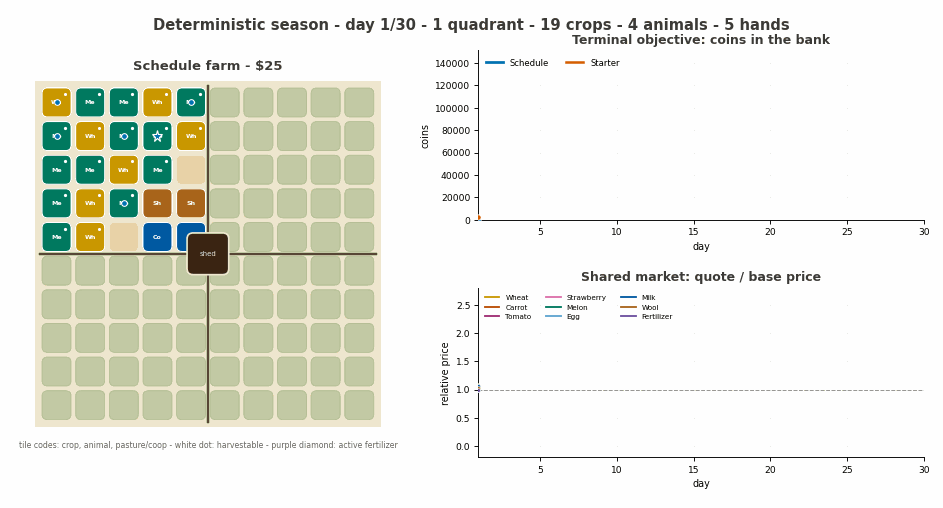

In [5]:
import base64
from io import BytesIO

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from PIL import Image as PILImage
from IPython.display import HTML, display
from kaggle_environments import make
from kaggle_environments.envs.kaggriculture.kaggriculture import MARKET_PARAMS

SEASON_SEED = 217
SEASON_FRAME_MS = 1500
SEASON_DPI = 82

season_env = make(
    "kaggriculture",
    configuration={"episodeSteps": 720, "seed": SEASON_SEED},
    debug=True,
)
season_env.run([str(MAIN_PATH), "starter"])
season_steps = season_env.steps
assert len(season_steps) == 720
assert all(str(player.status) == "DONE" for player in season_steps[-1])

turns_per_day = int(season_env.configuration.turnsPerDay)
frame_indices = [
    min(turns_per_day * day - 1, len(season_steps) - 1)
    for day in range(1, 31)
]
assert len(frame_indices) == len(set(frame_indices)) == 30

daily_observations = [
    season_steps[index][0]["observation"] for index in frame_indices
]
day_axis = list(range(1, len(daily_observations) + 1))

CROP_COLORS = {
    "WHEAT": "#C99700",
    "CARROT": "#B84A00",
    "TOMATO": "#9E2B72",
    "STRAWBERRY": "#DB6FA9",
    "MELON": "#00795F",
}
PRODUCT_COLORS = {
    **CROP_COLORS,
    "EGG": "#56A8D8",
    "MILK": "#0059A1",
    "WOOL": "#A8641A",
    "FERTILIZER": "#6B4F9E",
}
CROP_LABELS = {
    "WHEAT": "Wh",
    "CARROT": "Ca",
    "TOMATO": "To",
    "STRAWBERRY": "St",
    "MELON": "Me",
}
ANIMAL_LABELS = {"CHICKEN": "Ch", "COW": "Co", "SHEEP": "Sh", "GOOSE": "Go"}
ANIMAL_PRODUCTS = {"CHICKEN": "EGG", "COW": "MILK", "SHEEP": "WOOL", "GOOSE": "EGG"}
SOIL = "#EFE7CE"
TILLED = "#E8D2A6"
WILD = "#C2CAA4"
WOOD = "#8B6F44"
WOOD_DARK = "#3A2412"
INK = "#3C3B37"
SCHEDULE_COLOR = "#0072B2"
STARTER_COLOR = "#D55E00"


def draw_schedule_farm(axis, farm, day=None):
    board_size = len(farm["tiles"])

    def rounded_tile(x, y, facecolor, edgecolor="white", linewidth=0.8, alpha=1.0):
        axis.add_patch(
            FancyBboxPatch(
                (x + 0.07, board_size - 1 - y + 0.07),
                0.86,
                0.86,
                boxstyle="round,pad=0,rounding_size=0.16",
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth,
                alpha=alpha,
            )
        )

    axis.add_patch(
        plt.Rectangle(
            (-0.15, -0.15),
            board_size + 0.30,
            board_size + 0.30,
            facecolor=SOIL,
            edgecolor="none",
            zorder=0,
        )
    )
    for y, row in enumerate(farm["tiles"]):
        for x, tile in enumerate(row):
            if tile == "LOCKED":
                rounded_tile(x, y, WILD, "#B3BD94")
                continue
            rounded_tile(x, y, TILLED, SOIL)
            if not isinstance(tile, dict):
                continue
            kind = tile.get("kind")
            center = (x + 0.50, board_size - 1 - y + 0.50)
            if kind == "PLANT":
                crop = tile["crop"]
                harvestable = tile.get("yield_units", 0) > 0
                rounded_tile(
                    x, y, CROP_COLORS[crop], alpha=1.0 if harvestable else 0.45
                )
                axis.text(
                    *center,
                    CROP_LABELS[crop],
                    ha="center",
                    va="center",
                    fontsize=5.5,
                    color="white" if harvestable else INK,
                    weight="bold",
                    zorder=6,
                )
                if harvestable:
                    axis.plot(
                        center[0] + 0.25,
                        center[1] + 0.25,
                        "o",
                        markersize=2.8,
                        markerfacecolor="white",
                        markeredgecolor="none",
                        zorder=7,
                    )
                fertilized_until = tile.get("fertilized_until_day", -1)
                if (
                    day is not None
                    and fertilized_until is not None
                    and int(fertilized_until) >= int(day)
                ):
                    axis.plot(
                        center[0] - 0.25,
                        center[1] + 0.25,
                        marker="D",
                        markersize=4.8,
                        markerfacecolor=PRODUCT_COLORS["FERTILIZER"],
                        markeredgecolor="white",
                        markeredgewidth=0.7,
                        zorder=7,
                    )
            elif kind == "WEED":
                rounded_tile(x, y, "#6E7351", alpha=0.60)
                axis.text(
                    *center,
                    "x",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white",
                    weight="bold",
                    zorder=6,
                )
            elif "animal" in tile:
                animal = tile["animal"]
                rounded_tile(x, y, PRODUCT_COLORS[ANIMAL_PRODUCTS[animal]])
                axis.text(
                    *center,
                    ANIMAL_LABELS[animal],
                    ha="center",
                    va="center",
                    fontsize=5.5,
                    color="white",
                    weight="bold",
                    zorder=6,
                )
            elif kind in ("COOP", "PASTURE"):
                rounded_tile(x, y, WOOD, alpha=0.55)
                axis.text(
                    *center,
                    "Cp" if kind == "COOP" else "Pa",
                    ha="center",
                    va="center",
                    fontsize=5.5,
                    color="white",
                    weight="bold",
                    zorder=6,
                )

    half = board_size / 2
    axis.plot(
        [half, half], [0, board_size],
        color=WOOD_DARK, linewidth=2.1, alpha=0.82, zorder=4,
    )
    axis.plot(
        [0, board_size], [half, half],
        color=WOOD_DARK, linewidth=2.1, alpha=0.82, zorder=4,
    )
    axis.add_patch(
        FancyBboxPatch(
            (half - 0.62, half - 0.62),
            1.24,
            1.24,
            boxstyle="round,pad=0,rounding_size=0.18",
            facecolor=WOOD_DARK,
            edgecolor=SOIL,
            linewidth=1.5,
            zorder=7,
        )
    )
    axis.text(
        half, half, "shed",
        ha="center", va="center", fontsize=6.2, color=SOIL, zorder=8,
    )

    farmer_x, farmer_y = farm["farmer"]
    axis.plot(
        farmer_x + 0.50,
        board_size - 1 - farmer_y + 0.50,
        marker="*",
        markersize=10,
        markerfacecolor=SCHEDULE_COLOR,
        markeredgecolor="white",
        markeredgewidth=1.0,
        zorder=9,
    )
    for hand_x, hand_y in farm.get("hands", []):
        axis.plot(
            hand_x + 0.50,
            board_size - 1 - hand_y + 0.50,
            "o",
            markersize=5,
            markerfacecolor=SCHEDULE_COLOR,
            markeredgecolor="white",
            markeredgewidth=0.9,
            zorder=9,
        )

    axis.set_xlim(-0.20, board_size + 0.20)
    axis.set_ylim(-0.20, board_size + 0.20)
    axis.set_aspect("equal")
    axis.axis("off")
    axis.grid(False)


PRICE_PRODUCTS = tuple(MARKET_PARAMS)
bank_history = {
    "Schedule": [
        float(observation["farms"][0]["money"])
        for observation in daily_observations
    ],
    "Starter": [
        float(observation["farms"][1]["money"])
        for observation in daily_observations
    ],
}
price_history = {
    item: [
        float(observation["market"]["prices"][item])
        / MARKET_PARAMS[item]["base"]
        for observation in daily_observations
    ]
    for item in PRICE_PRODUCTS
}

bank_ceiling = 1.08 * max(max(values) for values in bank_history.values())
all_price_ratios = [
    value for values in price_history.values() for value in values
]
ratio_span = max(all_price_ratios) - min(all_price_ratios)
ratio_pad = max(0.05, 0.08 * ratio_span)
ratio_limits = (
    min(all_price_ratios) - ratio_pad,
    max(all_price_ratios) + ratio_pad,
)

figure = plt.figure(figsize=(11.5, 6.2), dpi=SEASON_DPI, facecolor="white")
grid = figure.add_gridspec(
    2, 2, width_ratios=(1.02, 1.30), height_ratios=(1, 1)
)
farm_axis = figure.add_subplot(grid[:, 0])
bank_axis = figure.add_subplot(grid[0, 1])
market_axis = figure.add_subplot(grid[1, 1])
figure.subplots_adjust(
    left=0.035, right=0.98, bottom=0.10, top=0.90, wspace=0.24, hspace=0.40
)


def style_series_axis(axis):
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(alpha=0.20, linewidth=0.7)
    axis.tick_params(labelsize=8)


def render_season_frame(frame_number):
    farm_axis.clear()
    bank_axis.clear()
    market_axis.clear()

    observation = daily_observations[frame_number]
    farm = observation["farms"][0]
    draw_schedule_farm(
        farm_axis, farm, day=int(observation.get("day", 0) or 0)
    )

    tiles = [tile for row in farm["tiles"] for tile in row]
    plant_count = sum(
        isinstance(tile, dict) and tile.get("kind") == "PLANT"
        for tile in tiles
    )
    animal_count = sum(
        isinstance(tile, dict) and "animal" in tile for tile in tiles
    )
    unlocked = len(farm.get("unlocked_quadrants", []))
    farm_axis.set_title(
        f"Schedule farm - ${farm['money']:,.0f}",
        fontsize=11.5,
        color=INK,
        weight="bold",
        pad=8,
    )
    farm_axis.text(
        0.5,
        -0.035,
        (
            "tile codes: crop, animal, pasture/coop - white dot: "
            "harvestable - purple diamond: active fertilizer"
        ),
        transform=farm_axis.transAxes,
        ha="center",
        va="top",
        fontsize=6.9,
        color="#6A6861",
        linespacing=1.35,
    )

    visible_days = day_axis[: frame_number + 1]
    bank_axis.plot(
        visible_days,
        bank_history["Schedule"][: frame_number + 1],
        color=SCHEDULE_COLOR,
        linewidth=2.4,
        label="Schedule",
    )
    bank_axis.plot(
        visible_days,
        bank_history["Starter"][: frame_number + 1],
        color=STARTER_COLOR,
        linewidth=2.2,
        label="Starter",
    )
    for label, color in (
        ("Schedule", SCHEDULE_COLOR),
        ("Starter", STARTER_COLOR),
    ):
        bank_axis.scatter(
            visible_days[-1],
            bank_history[label][frame_number],
            s=22,
            color=color,
            edgecolor="white",
            linewidth=0.7,
            zorder=5,
        )
    bank_axis.set_xlim(1, 30)
    bank_axis.set_ylim(0, bank_ceiling)
    bank_axis.set_title(
        "Terminal objective: coins in the bank",
        fontsize=11,
        color=INK,
        weight="bold",
    )
    bank_axis.set_xlabel("day", fontsize=8.5)
    bank_axis.set_ylabel("coins", fontsize=8.5)
    bank_axis.legend(loc="upper left", frameon=False, fontsize=7.5, ncol=2)
    style_series_axis(bank_axis)

    for item in PRICE_PRODUCTS:
        market_axis.plot(
            visible_days,
            price_history[item][: frame_number + 1],
            color=PRODUCT_COLORS[item],
            linewidth=1.6,
            label=item.title(),
        )
        market_axis.scatter(
            visible_days[-1],
            price_history[item][frame_number],
            s=12,
            color=PRODUCT_COLORS[item],
            edgecolor="white",
            linewidth=0.5,
            zorder=5,
        )
    market_axis.axhline(
        1.0, color="#7A7770", linewidth=0.9, linestyle="--", alpha=0.75
    )
    market_axis.set_xlim(1, 30)
    market_axis.set_ylim(*ratio_limits)
    market_axis.set_title(
        "Shared market: quote / base price",
        fontsize=11,
        color=INK,
        weight="bold",
    )
    market_axis.set_xlabel("day", fontsize=8.5)
    market_axis.set_ylabel("relative price", fontsize=8.5)
    market_axis.legend(loc="upper left", frameon=False, fontsize=6.4, ncol=3)
    style_series_axis(market_axis)

    figure.suptitle(
        (
            f"Deterministic season - day {frame_number + 1}/30 - "
            f"{unlocked} {'quadrant' if unlocked == 1 else 'quadrants'} - "
            f"{plant_count} crops - {animal_count} animals - "
            f"{len(farm.get('hands', []))} hands"
        ),
        fontsize=13,
        color=INK,
        weight="bold",
        y=0.965,
    )


rendered_frames = []
for frame_number in range(len(frame_indices)):
    render_season_frame(frame_number)
    frame_buffer = BytesIO()
    figure.savefig(
        frame_buffer, format="png", dpi=SEASON_DPI, facecolor="white"
    )
    frame_buffer.seek(0)
    with PILImage.open(frame_buffer) as frame_image:
        rendered_frames.append(frame_image.convert("RGBA"))

animation_buffer = BytesIO()
rendered_frames[0].save(
    animation_buffer,
    format="GIF",
    save_all=True,
    append_images=rendered_frames[1:],
    duration=SEASON_FRAME_MS,
    loop=0,
    disposal=2,
    optimize=True,
)
plt.close(figure)
for frame_image in rendered_frames:
    frame_image.close()
gif_bytes = animation_buffer.getvalue()

with PILImage.open(BytesIO(gif_bytes)) as rendered_gif:
    gif_dimensions = rendered_gif.size
    gif_frames = rendered_gif.n_frames
    gif_loop = rendered_gif.info.get("loop")

assert gif_frames == 30
assert gif_loop == 0
assert gif_bytes[:6] in (b"GIF87a", b"GIF89a")

animation_alt = (
    "Thirty-day deterministic farm, bank, and shared-market season "
    "under the committed program."
)
gif_base64 = base64.b64encode(gif_bytes).decode("ascii")
animation_html = (
    '<img src="data:image/gif;base64,'
    + gif_base64
    + '" alt="'
    + animation_alt
    + f'" width="{gif_dimensions[0]}" height="{gif_dimensions[1]}" '
    + 'style="display:block;width:100%;max-width:'
    + f'{gif_dimensions[0]}px;height:auto;margin:0 auto;" />'
)
display(HTML(animation_html))


## 6. Market position through the season

The animation reads price as a time series; this figure reads it as a
position. For each product, the season's daily inventory
$\{I_{r,i_d}\}_{d=1}^{30}$ is placed on that product's own quote curve
$p_r(\cdot)/b_r$, one panel per product, coloured by day. The dashed
line marks the equilibrium inventory $I_0$; for the three knee-shaped
products the dotted line marks the knee at $I_0-T_r$. Which side of
$I_0$ a product spends its season on - and whether its path ever
crosses the knee - is the entire pricing story of Section 1, read off
directly.



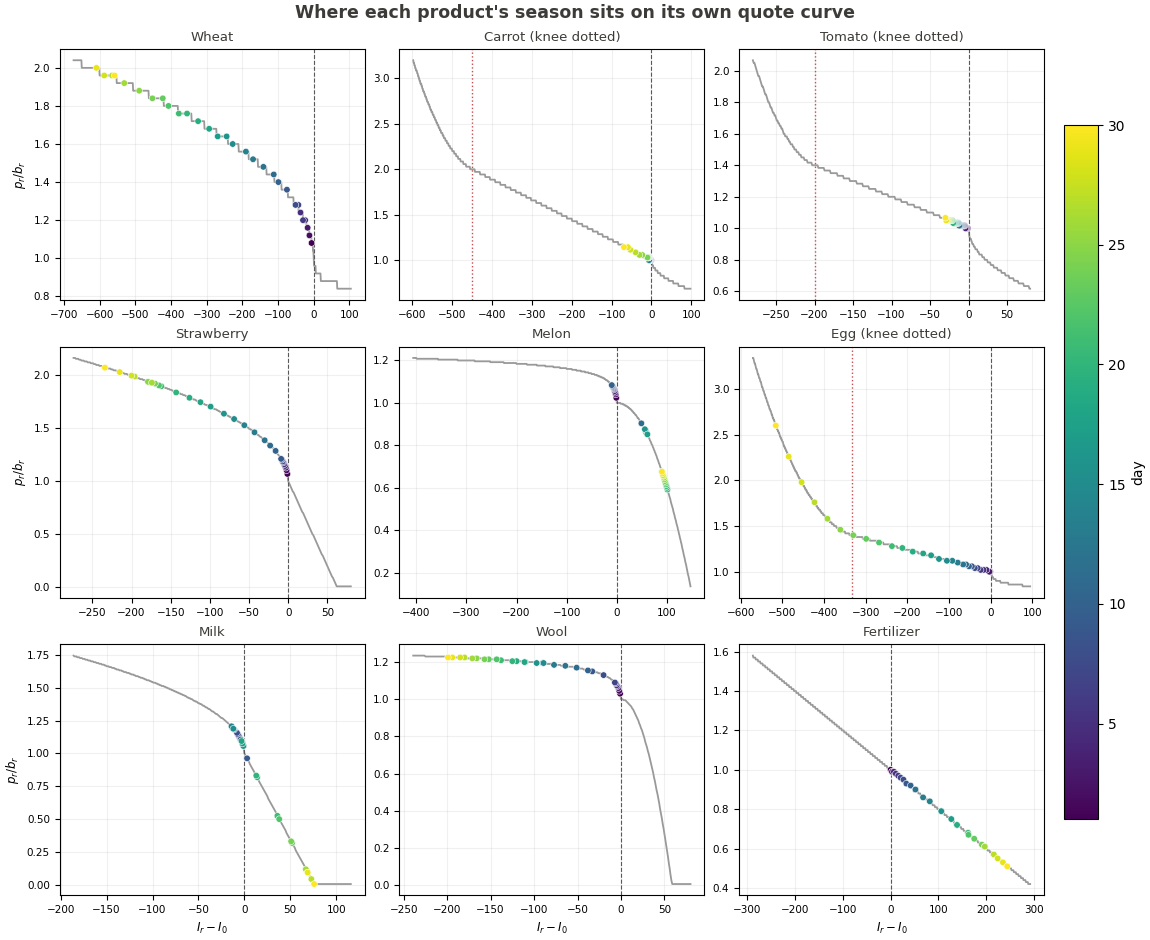

In [6]:
import base64
import io

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from kaggle_environments.envs.kaggriculture.kaggriculture import (
    MARKET_I0,
    MARKET_PARAMS,
    market_price,
)

POSITION_DPI = 100
_ink = "#3C3B37"
panel_products = tuple(MARKET_PARAMS)
assert len(panel_products) == 9

daily_inventory = {
    item: [
        int(observation["market"]["inventory"][item])
        for observation in daily_observations
    ]
    for item in panel_products
}

position_figure, position_axes = plt.subplots(
    3, 3, figsize=(11.5, 9.4), dpi=POSITION_DPI, constrained_layout=True
)
season_scatter = None
for axis, item in zip(position_axes.flat, panel_products):
    params = MARKET_PARAMS[item]
    inventory_path = daily_inventory[item]
    low = min(min(inventory_path), MARKET_I0 - int(1.2 * params["T"]))
    high = max(max(inventory_path), MARKET_I0 + 40)
    pad = max(40, (high - low) // 10)
    inventory_grid = np.arange(low - pad, high + pad + 1)
    curve = np.array(
        [market_price(item, int(value)) for value in inventory_grid],
        dtype=float,
    )
    axis.plot(
        inventory_grid - MARKET_I0,
        curve / params["base"],
        color="0.60",
        lw=1.3,
        zorder=1,
    )
    axis.axvline(0.0, color="0.35", lw=0.8, ls="--", zorder=2)
    if params["below_func"] == "hinge":
        axis.axvline(
            -float(params["T"]), color="#C44E52", lw=1.0, ls=":", zorder=2
        )
    day_quotes = np.array(
        [market_price(item, int(value)) for value in inventory_path],
        dtype=float,
    )
    season_scatter = axis.scatter(
        np.array(inventory_path, dtype=float) - MARKET_I0,
        day_quotes / params["base"],
        c=day_axis,
        cmap="viridis",
        vmin=1,
        vmax=30,
        s=22,
        zorder=3,
        edgecolor="white",
        linewidth=0.4,
    )
    knee_note = " (knee dotted)" if params["below_func"] == "hinge" else ""
    axis.set_title(item.title() + knee_note, fontsize=9.5, color=_ink)
    axis.grid(alpha=0.18)
    axis.tick_params(labelsize=7.5)
for axis in position_axes[-1]:
    axis.set_xlabel(r"$I_r-I_0$", fontsize=8.5)
for row in position_axes:
    row[0].set_ylabel(r"$p_r/b_r$", fontsize=8.5)
position_figure.colorbar(
    season_scatter, ax=position_axes, shrink=0.82, pad=0.02, label="day"
)
position_figure.suptitle(
    "Where each product's season sits on its own quote curve",
    fontsize=12.5,
    color=_ink,
    weight="bold",
)
position_buffer = io.BytesIO()
position_figure.savefig(
    position_buffer, format="png", dpi=POSITION_DPI, facecolor="white"
)
plt.close(position_figure)
png_bytes = position_buffer.getvalue()
assert png_bytes[:8] == b"\x89PNG\r\n\x1a\n"
display(HTML(
    '<img src="data:image/png;base64,'
    + base64.b64encode(png_bytes).decode("ascii")
    + '" alt="Per-product season path on its own quote curve." '
    + 'style="display:block;width:100%;max-width:1150px;height:auto;'
    + 'margin:0 auto;" />'
))


In [7]:
import gzip
import hashlib
import io
import tarfile

payload = MAIN_PATH.read_bytes()
raw = io.BytesIO()
with gzip.GzipFile(
    fileobj=raw,
    mode="wb",
    filename="",
    mtime=0,
) as zipped:
    with tarfile.open(fileobj=zipped, mode="w") as archive:
        info = tarfile.TarInfo("main.py")
        info.size = len(payload)
        info.mode = 0o644
        info.mtime = 0
        info.uid = info.gid = 0
        info.uname = info.gname = ""
        archive.addfile(info, io.BytesIO(payload))

archive_path = WORK_DIR / "submission.tar.gz"
archive_path.write_bytes(raw.getvalue())
with tarfile.open(archive_path, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]
    assert archive.extractfile("main.py").read() == payload

print(
    {
        "archive": archive_path.name,
        "main_sha256": hashlib.sha256(payload).hexdigest(),
        "archive_sha256": hashlib.sha256(
            archive_path.read_bytes()
        ).hexdigest(),
    }
)


{'archive': 'submission.tar.gz', 'main_sha256': '8b9983d62293bcaabe73b326a67f1a49e275be10b32a6ff55c04044a5dc2d906', 'archive_sha256': '6f4232b34c1a0bcd92f94d5907819a1bf738b9fb06243c2cbe94c9e72db5d8a4'}
